<a href="https://colab.research.google.com/github/MigXDev/CS_Datos_I_DESAFIO_2/blob/main/Modelo_RandomForest_I_(TARG_DESP).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


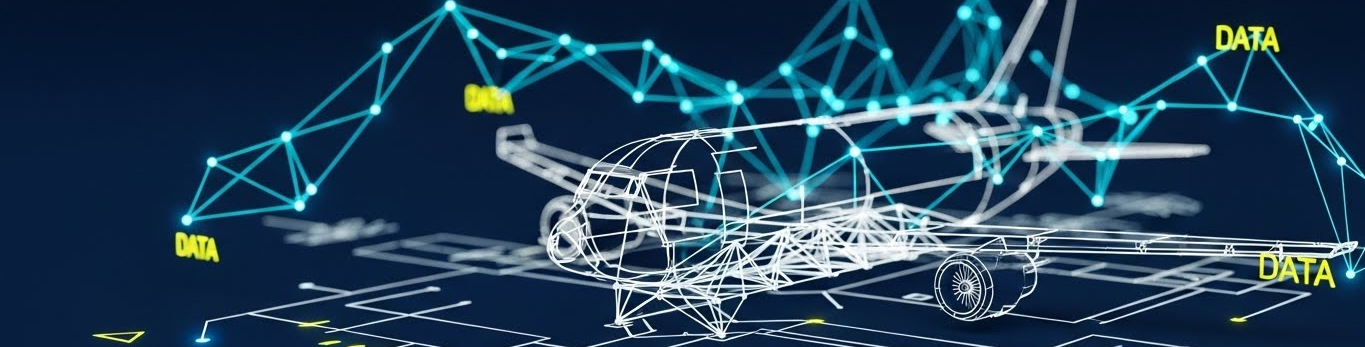

---

# **MODELADO PREDICTIVO- RandomForest | Predicción de Retrasos de Vuelos (FlightOnTime)**


**Proyecto:** FlightOnTime - Sistema de Predicción de Retrasos de Vuelos  
**Versión:** 2.0 | **Estado:** `[LISTO PARA PRODUCCIÓN]`  
**Última Actualización:** 2026-01-10  
**Autor:** Equipo de Data Science

### **Descripción rapida**
Solución predictiva basada en Random Forest que estima con **68% de precisión**
si un vuelo comercial despegará con retraso, utilizando exclusivamente información
disponible antes del despegue. El modelo identifica patrones críticos en aerolíneas,
aeropuertos y condiciones temporales para alertas proactivas.


---

## **Tabla de Contenidos**

### **Parte I: Contexto y Configuración**
1. [Contexto del Proyecto y Definición del Problema](#1-contexto-del-proyecto-y-definición-del-problema)
2. [Configuración del Entorno](#2-configuración-del-entorno)

### **Parte II: Ingeniería de Datos**
3. [Carga y Revision de Datos](#3-carga-y-revision-de-datos)
4. [Limpieza y Optimización](#4-limpieza-y-optimización)
5. [Feature Engineering](#5-feature-engineering)

### **Parte III: Preparación para Modelado**
6. [División de Datos y Balanceo de Clases](#6-división-de-datos-y-balanceo-de-clases)
7. [Definición de Conjuntos de Features](#7-definición-de-conjuntos-de-features)

### **Parte IV: Modelado y Optimización**
8. [Modelado Predictivo y Experimentacion](#8-modelado-predictivo-y-experimentacion)
9. [Optimización de Hiperparámetros](#9-optimización-de-hiperparámetros)

### **Parte V: Validación y Despliegue**
10. [Evaluación Comparativa de Modelos](#10-evaluación-comparativa-de-modelos)
11. [Preparación para Producción](#11-preparación-para-producción)

### **Apéndices**
12. [Conclusiones y Recomendaciones](#12-conclusiones-y-recomendaciones)
13. [Glosario de Términos](#13-glosario-de-términos)

---

<a id="1-contexto-del-proyecto-y-definición-del-problema"></a>
## **1. Contexto del Proyecto y Definición del Problema**

### **1.1. Problema de Negocio**

**Sector:** Aviación Civil / Logística / Transporte Aéreo  
**Stakeholders (Areas de interesadas):** Aerolíneas, aeropuertos y pasajeros que dependen de la puntualidad de los vuelos.

**Impacto del Problema:**
- **Insatisfacción de pasajeros:** Conexiones perdidas, planes de viaje interrumpidos
- **Costos operativos:** Multas, compensaciones, combustible adicional
- **Ineficiencias logísticas:** Sobrecarga en aeropuertos, reprogramación de tripulaciones


### **1.2. Objetivo del Modelado**

Desarrollar un **modelo predictivo binario** que identifique vuelos con alto riesgo de retraso en el despegue, utilizando únicamente información disponible **antes de la operación del vuelo**.

**Definición Técnica:**
- **Target:** `TARG_DESP` = Retraso en salida > 15 minutos
- **Umbral:** 15 minutos (estándar DOT - Department of Transportation)
- **Horizonte Predictivo:** Pre-despegue (información disponible en sistema de reservas)

### **1.3. Alcance del MVP**
| Componente | Especificación | Justificación |
|------------|----------------|---------------|
| **Tipo de Modelo** | Clasificación binaria | Predicción (**Sí/No**) de retraso |
| **Algoritmo** | Random Forest | Robustez, interpretabilidad, manejo de features mixtas |
| **Features** | Información pre-vuelo | Validez operacional (no data leakage) |
| **Entregable** | Modelo serializado + FAST-API | Integración con sistemas existentes |


<a id="2-configuración-del-entorno"></a>
## **2. Configuración del Entorno**

### **2.1. Objetivo**
Configurar un entorno reproducible con versiones específicas de librerías para garantizar la consistencia de resultados.


### **2.2. Librerías y Versiones**

In [1]:
# ============================================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================================

# Manipulación y análisis de datos
import pandas as pd # Estructuras de datos (DataFrames) y análisis tabular
import numpy as np  # Cálculo numérico y manejo de matrices
from pandas.tseries.holiday import USFederalHolidayCalendar # Gestión de dias festivos en EEUU

# Visualización de datos
import matplotlib.pyplot as plt # Creación de gráficos base
import seaborn as sns           # Visualización estadística avanzada y estética

# Machine Learning y metricas de evaluacion (Scikit-learn)
from sklearn.metrics import (classification_report, confusion_matrix,
                             RocCurveDisplay, roc_auc_score, accuracy_score)

from sklearn.model_selection import train_test_split, GridSearchCV # División de datos y optimización
from sklearn.ensemble import RandomForestClassifier                # Modelo de Bosques Aleatorios
from sklearn.preprocessing import LabelEncoder                     # Codificación de variables categóricas
from sklearn.utils import resample                                 # Manejo de desbalanceo de clases
from sklearn.feature_selection import RFE                          # Selección recursiva de características

# Utilidades
from datetime import datetime # Manejo de formatos de fecha y hora
from time import time         # Medición de tiempos de ejecución
import warnings               # Gestión de mensajes de advertencia del sistema
import joblib                 # Guardado y carga de modelos entrenados


# ============================================================================
# CONFIGURACIÓN GLOBAL
# ===========================================hol=================================

# Configuración de reproducibilidad
RANDOM_STATE = 42
TEST_SIZE = 0.2
UMBRAL_RETRASO = 15  # minutos

# Suprimir warnings innecesarios
warnings.filterwarnings('ignore')

# Configuración de pandas para mejor visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Se define una paleta consistente para todas las visualizaciones, facilitando la interpretación de resultados
COLORES = {
    'puntual': '#2ecc71',      # Verde - Vuelos puntuales
    'retrasado': '#e74c3c',    # Rojo - Vuelos retrasados
    'neutro': '#3498db',       # Azul - Datos generales
    'advertencia': '#f39c12',  # Naranja - Alertas
    'compensado': '#9b59b6'    # Púrpura - Casos especiales
}

# Estilo de visualizaciones
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Entorno configurado correctamente")
print(f"Versión de pandas: {pd.__version__}")
print(f"Versión de numpy: {np.__version__}")

Entorno configurado correctamente
Versión de pandas: 2.2.2
Versión de numpy: 2.0.2


### **2.3. Justificación Técnica**
- **Reproducibilidad:** `RANDOM_STATE=42` garantiza resultados consistentes
- **Versiones específicas:** Evita cambios de comportamiento en librerías
- **Optimización de memoria:** Configuración de pandas para datasets grandes

<a id="3-carga-y-revision-de-datos"></a>
## **3. Carga y Revision de Datos**

### **3.1. Objetivo**
Cargar el dataset histórico de vuelos desde la fuente de datos (Kaggle) y hacer una analisis completo para validar su estado y calidad.

### **Descripción del Dataset**

Este dataset contiene información de operaciones aéreas comerciales incluyendo horarios programados, retrasos, aerolíneas, aeropuertos y condiciones operacionales.

El dataset incluye variables relacionadas con:
- **Identificación**: Aerolínea, número de vuelo, fecha
- **Rutas**: Aeropuerto de origen y destino, distancia
- **Horarios**: Tiempos programados y reales de salida/llegada
- **Operación**: Tiempos de transporte a puerta de embarque, rodaje, vuelo en el aire
- **Retrasos**: Minutos de retraso y causas específicas
- **Estados**: Vuelos cancelados o desviados

### **3.2. Procedimiento**

In [2]:
# ============================================================================
# CARGA DE DATOS
# ============================================================================
print("Cargando Dataset (Vuelos)...")
url = 'vuelos.csv'
df = pd.read_csv(url)
print(f"Dataset cargado exitosamente: {df.shape[0]:,} registros × {df.shape[1]} columnas")

# ============================================================================
# INSPECCIÓN INICIAL
# ============================================================================
print("\nPRIMERAS 3 FILAS DEL DATASET:")
display(df.head(3))

print("\nÚLTIMAS 3 FILAS DEL DATASET:")
display(df.tail(3))

Cargando Dataset (Vuelos)...
Dataset cargado exitosamente: 3,000,000 registros × 32 columnas

PRIMERAS 3 FILAS DEL DATASET:


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",1155,1151.00,-4.00,19.00,1210.00,1443.00,4.00,1501,1447.00,-14.00,0.00,NaN,0.00,186.00,176.00,153.00,1065.00,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",2120,2114.00,-6.00,9.00,2123.00,2232.00,38.00,2315,2310.00,-5.00,0.00,NaN,0.00,235.00,236.00,189.00,1399.00,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",954,1000.00,6.00,20.00,1020.00,1247.00,5.00,1252,1252.00,0.00,0.00,NaN,0.00,118.00,112.00,87.00,680.00,NaN,NaN,NaN,NaN,NaN



ÚLTIMAS 3 FILAS DEL DATASET:


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
2999997,2022-09-11,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2745,HSV,"Huntsville, AL",ATL,"Atlanta, GA",534,615.00,41.00,16.00,631.00,759.00,6.00,729,805.00,36.00,0.00,NaN,0.00,55.00,50.00,28.00,151.00,0.00,36.00,0.00,0.00,0.00
2999998,2019-11-13,Republic Airline,Republic Airline: YX,YX,20452,6134,BOS,"Boston, MA",LGA,"New York, NY",1600,1555.00,-5.00,19.00,1614.00,1704.00,8.00,1728,1712.00,-16.00,0.00,NaN,0.00,88.00,77.00,50.00,184.00,NaN,NaN,NaN,NaN,NaN
2999999,2019-06-15,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,2823,LGB,"Long Beach, CA",SJC,"San Jose, CA",730,727.00,-3.00,9.00,736.00,828.00,2.00,840,830.00,-10.00,0.00,NaN,0.00,70.00,63.00,52.00,324.00,NaN,NaN,NaN,NaN,NaN


In [3]:
print("INFORMACIÓN GENERAL DEL DATASET:")
df.info()

print("\nESTADÍSTICAS DESCRIPTIVAS:")
df.describe()

INFORMACIÓN GENERAL DEL DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED    

,DOT_CODE,FL_NUMBER,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
count,3000000.00,3000000.00,3000000.00,2922385.00,2922356.00,2921194.00,2921194.00,2920056.00,2920056.00,3000000.00,2920058.00,2913802.00,3000000.00,3000000.00,2999986.00,2913802.00,2913802.00,3000000.00,533863.00,533863.00,533863.00,533863.00,533863.00
mean,19976.29,2511.54,1327.06,1329.78,10.12,16.64,1352.36,1462.50,7.68,1490.56,1466.51,4.26,0.03,0.00,142.28,136.62,112.31,809.36,24.76,3.99,13.16,0.15,25.47
std,377.28,1747.26,485.88,499.31,49.25,9.19,500.87,527.24,6.27,511.55,531.84,51.17,0.16,0.05,71.56,71.68,69.75,587.89,71.77,32.41,33.16,3.58,55.77
min,19393.00,1.00,1.00,1.00,-90.00,1.00,1.00,1.00,1.00,1.00,1.00,-96.00,0.00,0.00,1.00,15.00,8.00,29.00,0.00,0.00,0.00,0.00,0.00
25%,19790.00,1051.00,915.00,916.00,-6.00,11.00,931.00,1049.00,4.00,1107.00,1053.00,-16.00,0.00,0.00,90.00,84.00,61.00,377.00,0.00,0.00,0.00,0.00,0.00
50%,19930.00,2152.00,1320.00,1323.00,-2.00,14.00,1336.00,1501.00,6.00,1516.00,1505.00,-7.00,0.00,0.00,125.00,120.00,95.00,651.00,4.00,0.00,0.00,0.00,0.00
75%,20368.00,3797.00,1730.00,1739.00,6.00,19.00,1752.00,1908.00,9.00,1919.00,1913.00,7.00,0.00,0.00,172.00,167.00,142.00,1046.00,23.00,0.00,17.00,0.00,30.00
max,20452.00,9562.00,2359.00,2400.00,2966.00,184.00,2400.00,2400.00,249.00,2400.00,2400.00,2934.00,1.00,1.00,705.00,739.00,692.00,5812.00,2934.00,1653.00,1741.00,1185.00,2557.00


### **3.3. Análisis de Valores Nulos**


Los valores nulos pueden indicar:
- Información no registrada durante la operación
- Datos no aplicables según el contexto del vuelo
- Errores en la recopilación de datos

In [4]:
# ============================================================================
# ANÁLISIS DE VALORES NULOS
# ============================================================================
cant_nulos = df.isnull().sum()
porc_nulos = (cant_nulos / len(df)) * 100

resumen_nulos = pd.DataFrame({
    'Cantidad_Nulos': cant_nulos,
    'Porcentaje': porc_nulos
})

resumen_nulos = resumen_nulos[resumen_nulos['Cantidad_Nulos'] > 0].sort_values(
    'Cantidad_Nulos', ascending=False
)

if len(resumen_nulos) > 0:
  print("COLUMNAS CON VALORES NULOS:\n")
  display(resumen_nulos)
else:
  print("No hay valores nulos en el dataset")

COLUMNAS CON VALORES NULOS:



,Cantidad_Nulos,Porcentaje
CANCELLATION_CODE,2920860,97.36
DELAY_DUE_WEATHER,2466137,82.20
DELAY_DUE_NAS,2466137,82.20
DELAY_DUE_SECURITY,2466137,82.20
DELAY_DUE_LATE_AIRCRAFT,2466137,82.20
DELAY_DUE_CARRIER,2466137,82.20
AIR_TIME,86198,2.87
ELAPSED_TIME,86198,2.87
ARR_DELAY,86198,2.87
TAXI_IN,79944,2.66


### **3.4. Variables unicas Clave**

Evaluamos e identificamos la cantidad de variables unicas presentes en nuestros dataset, para su posterior uso en el modelo


In [5]:
# ============================================================================
# ANÁLISIS DE VALORES ÚNICOS (Solo columnas relevantes)
# ============================================================================
print("="*80)
print("ANÁLISIS DE VALORES ÚNICOS")
print("="*80 + "\n")

# 1. Calcular la cantidad de valores únicos por columna
conteo_unicos = {
    col: df[col].nunique(dropna=False)
    for col in df.columns
}
# 2. Ordenar las columnas de mayor a menor según valores únicos
columnas_ordenadas = sorted(
    conteo_unicos,
    key=conteo_unicos.get,
    reverse=True
)
# 3. Mostrar resultados
for col in columnas_ordenadas:
    unicos = conteo_unicos[col]
    print(f"Columna '{col}': {unicos} valores únicos")
    # Mostrar valores únicos solo si son pocos
    if unicos <= 50:
        print(f"{df[col].unique()}\n")

# ============================================================================
# ANÁLISIS DE DUPLICADOS
# ============================================================================

num_duplicados = df.duplicated().sum()
print("="*80)
print("ANÁLISIS DE DUPLICADOS")
print("="*80)
print(f"Filas duplicadas: {num_duplicados} ({num_duplicados/len(df)*100:.2f}%)")

ANÁLISIS DE VALORES ÚNICOS

Columna 'FL_NUMBER': 7111 valores únicos
Columna 'DISTANCE': 1727 valores únicos
Columna 'FL_DATE': 1704 valores únicos
Columna 'ARR_DELAY': 1528 valores únicos
Columna 'DEP_DELAY': 1514 valores únicos
Columna 'DEP_TIME': 1441 valores únicos
Columna 'WHEELS_OFF': 1441 valores únicos
Columna 'WHEELS_ON': 1441 valores únicos
Columna 'ARR_TIME': 1441 valores únicos
Columna 'CRS_ARR_TIME': 1435 valores únicos
Columna 'CRS_DEP_TIME': 1384 valores únicos
Columna 'DELAY_DUE_CARRIER': 1292 valores únicos
Columna 'DELAY_DUE_LATE_AIRCRAFT': 959 valores únicos
Columna 'DELAY_DUE_WEATHER': 813 valores únicos
Columna 'ELAPSED_TIME': 697 valores únicos
Columna 'DELAY_DUE_NAS': 672 valores únicos
Columna 'AIR_TIME': 667 valores únicos
Columna 'CRS_ELAPSED_TIME': 641 valores únicos
Columna 'ORIGIN': 380 valores únicos
Columna 'DEST': 380 valores únicos
Columna 'ORIGIN_CITY': 373 valores únicos
Columna 'DEST_CITY': 373 valores únicos
Columna 'TAXI_IN': 203 valores únicos
Col

### **3.5. Vuelos con Estados Operacionales Especiales**

Identificamos vuelos que no completaron su operación normal:

- **Vuelos Cancelados (`CANCELLED = 1`)**: No despegaron
- **Vuelos Desviados (`DIVERTED = 1`)**: Aterrizaron en aeropuerto diferente al destino

Estos registros serán **excluidos** del modelado porque:
1. No tienen datos completos de operación real
2. El objetivo es predecir retrasos en vuelos que efectivamente operan
3. La predicción de cancelaciones requiere un modelo diferente con otras variables



In [6]:
# ============================================================================
# EXPLORACIÓN DE ESTADOS OPERACIONALES
# ============================================================================

print("ANÁLISIS DE VUELOS CON ESTADOS ESPECIALES\n")

# Vuelos cancelados
num_cancelados = df['CANCELLED'].sum()
print(f"1. VUELOS CANCELADOS: {num_cancelados:,} ({num_cancelados/len(df)*100:.2f}%)")

if num_cancelados > 0:
    print("\nDistribución de códigos de cancelación:")
    print(df['CANCELLATION_CODE'].value_counts(dropna=False))
    print("\nMuestra de vuelos cancelados:")
    display(df[df['CANCELLED'] == 1].sample(3))

# Vuelos desviados
num_desviados = df['DIVERTED'].sum()
print(f"\n2. VUELOS DESVIADOS: {num_desviados:,} ({num_desviados/len(df)*100:.2f}%)")

if num_desviados > 0:
    print("\nMuestra de vuelos desviados:")
    display(df[df['DIVERTED'] == 1].sample(3))

# Resumen
print("\n" + "="*80)
print("RESUMEN DE ESTADOS")
print("="*80)
print(f"Vuelos operativos normales: {len(df) - num_cancelados - num_desviados:,}")
print(f"Vuelos a excluir: {num_cancelados + num_desviados:,}")
print(f"Porcentaje a retener: {(len(df) - num_cancelados - num_desviados)/len(df)*100:.2f}%")


ANÁLISIS DE VUELOS CON ESTADOS ESPECIALES

1. VUELOS CANCELADOS: 79,140.0 (2.64%)

Distribución de códigos de cancelación:
CANCELLATION_CODE
NaN    2920860
B        28772
D        24417
A        19476
C         6475
Name: count, dtype: int64

Muestra de vuelos cancelados:


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
992526,2021-02-16,Envoy Air,Envoy Air: MQ,MQ,20398,4081,DFW,"Dallas/Fort Worth, TX",AEX,"Alexandria, LA",1435,NaN,NaN,NaN,NaN,NaN,NaN,1548,NaN,NaN,1.00,B,0.00,73.00,NaN,NaN,285.00,NaN,NaN,NaN,NaN,NaN
324790,2019-04-13,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,84,DFW,"Dallas/Fort Worth, TX",LAX,"Los Angeles, CA",2215,NaN,NaN,NaN,NaN,NaN,NaN,2342,NaN,NaN,1.00,B,0.00,207.00,NaN,NaN,1235.00,NaN,NaN,NaN,NaN,NaN
1347514,2019-11-26,SkyWest Airlines Inc.,SkyWest Airlines Inc.: OO,OO,20304,5227,DEN,"Denver, CO",MFR,"Medford, OR",945,NaN,NaN,NaN,NaN,NaN,NaN,1141,NaN,NaN,1.00,B,0.00,176.00,NaN,NaN,964.00,NaN,NaN,NaN,NaN,NaN



2. VUELOS DESVIADOS: 7,056.0 (0.24%)

Muestra de vuelos desviados:


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
1928391,2022-05-17,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,1444,BNA,"Nashville, TN",MCO,"Orlando, FL",1735,1734.00,-1.00,13.00,1747.00,2130.00,10.00,2025,2140.00,NaN,0.00,NaN,1.00,110.00,NaN,NaN,616.00,NaN,NaN,NaN,NaN,NaN
246048,2023-01-02,SkyWest Airlines Inc.,SkyWest Airlines Inc.: OO,OO,20304,5515,GSP,"Greer, SC",DEN,"Denver, CO",841,838.00,-3.00,15.00,853.00,1515.00,11.00,1035,1526.00,NaN,0.00,NaN,1.00,234.00,NaN,NaN,1278.00,NaN,NaN,NaN,NaN,NaN
2815546,2023-04-26,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,2055,PHX,"Phoenix, AZ",SBP,"San Luis Obispo, CA",2007,2029.00,22.00,14.00,2043.00,1325.00,4.00,2146,1329.00,NaN,0.00,NaN,1.00,99.00,NaN,NaN,509.00,NaN,NaN,NaN,NaN,NaN



RESUMEN DE ESTADOS
Vuelos operativos normales: 2,913,804.0
Vuelos a excluir: 86,196.0
Porcentaje a retener: 97.13%


### **3.5. Impacto en el Modelado**


El análisis de calidad revela que aproximadamente **2,88% del dataset corresponde a vuelos cancelados (2,64%) o desviados (0,24%)**.  
Estos registros presentan:
- ausencia de tiempos reales de operación
- valores nulos sistemáticos en variables clave
- patrones que no representan retrasos operativos normales

Mantener estos registros produciría un sesgo estructural en el modelo, inflando artificialmente métricas como accuracy sin mejorar la capacidad predictiva real.  
Por este motivo, se decide **excluirlos completamente del modelado**, reservando su análisis para un problema distinto (predicción de cancelaciones).

<a id="4-limpieza-y-optimización"></a>
## **4. Limpieza y Optimización**

### **4.1. Objetivo**
Aplicar transformaciones para optimizar la eficiencia del dataset, uso de memoria y filtrado de registros no aplicables al problema de negocio

### **4.2. Optimización de Memoria**

Reducimos el uso de memoria convirtiendo tipos de datos a formatos más eficientes sin pérdida de información

In [7]:
# ============================================================================
# MEDICIÓN DE MEMORIA INICIAL
# ============================================================================

memoria_antes = df.memory_usage(deep=True).sum() / 1024**2
print(f"Memoria ANTES de optimización: {memoria_antes:.2f} MB")

# ============================================================================
# OPTIMIZACIÓN DE TIPOS DE DATOS
# ============================================================================

# 1. Fechas: `datetime64` permite operaciones temporales y extracción de features
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'], errors='coerce')

# 2. Enteros
df[['DOT_CODE', 'FL_NUMBER']] = df[['DOT_CODE', 'FL_NUMBER']].astype('int32')

# 3. Flotantes: `float32` mantiene precisión suficiente (7 decimales) para tiempos de vuelo
float_cols = [
    'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT',
    'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME',
    'ARR_TIME', 'ARR_DELAY', 'CRS_ELAPSED_TIME', 'ELAPSED_TIME',
    'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER',
    'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT'
]
# Rellenar NaN con 0 y convertir
df[float_cols] = df[float_cols].fillna(0).astype('float32')

# 4. Binarias: `CANCELLED` y `DIVERTED` solo tienen 2 valores (True/False)
df[['CANCELLED', 'DIVERTED']] = df[['CANCELLED', 'DIVERTED']].astype('bool')

# 5. Tratamiento de CANCELLATION_CODE
condiciones = [
    (df['CANCELLATION_CODE'].isna()) & (df['CANCELLED'] == False),
    (df['CANCELLATION_CODE'].isna()) & (df['CANCELLED'] == True)
]
resultados = ['NO_CANC', 'DESC']
df['CANCELLATION_CODE'] = np.select(condiciones, resultados, default=df['CANCELLATION_CODE'])

# 6. Categóricas: Las aerolíneas y aeropuertos se repiten, `category` es ideal
cat_cols = ['AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'CANCELLATION_CODE']
for col in cat_cols:
    df[col] = df[col].astype('category')

# ============================================================================
# MEDICIÓN DE MEMORIA FINAL
# ============================================================================

memoria_despues = df.memory_usage(deep=True).sum() / 1024**2
reduccion = ((memoria_antes - memoria_despues) / memoria_antes) * 100

print(f"Memoria DESPUÉS de optimización: {memoria_despues:.2f} MB")
print(f" - Reducción lograda: {reduccion:.2f}% ({memoria_antes - memoria_despues:.2f} MB ahorrados)")

Memoria ANTES de optimización: 1990.96 MB
Memoria DESPUÉS de optimización: 933.36 MB
 - Reducción lograda: 53.12% (1057.61 MB ahorrados)


### **4.3. Filtrado de Vuelos Operativos**

Creamos un dataset limpio que contiene únicamente vuelos que despegaron y aterrizaron normalmente, excluyendo cancelados y desviados.

> **IMPORTANTE**  
> Este filtrado es crítico para el modelado porque:
> - Los vuelos cancelados no tienen datos de operación real (`DEP_TIME`, `ARR_TIME` = `NaN`)
> - Los vuelos desviados tienen patrones atípicos que sesgarían el modelo
> - Nuestro objetivo es predecir retrasos en operaciones normales

In [8]:
# ============================================================================
# FILTRADO DE VUELOS OPERATIVOS
# ============================================================================

print("FILTRADO DE DATASET\n")
print(f"Registros originales: {len(df):,}")
print(f"  - Cancelados: {df['CANCELLED'].sum():,}")
print(f"  - Desviados: {df['DIVERTED'].sum():,}")

# Crear dataset filtrado (solo vuelos que operan normalmente)
df_limpio = df[(df['CANCELLED'] == False) & (df['DIVERTED'] == False)].copy()

print(f"\nRegistros después del filtrado: {len(df_limpio):,} ({len(df_limpio)/len(df)*100:.2f}%)")
print(f"Registros eliminados: {len(df) - len(df_limpio):,}")

# ============================================================================
# LIMPIEZA DE DATOS INCONSISTENTES
# ============================================================================

print("\n" + "="*80)
print("DETECCIÓN DE INCONSISTENCIAS")
print("="*80 + "\n")

# Detectar vuelos con AIR_TIME = 0 (físicamente imposible)
vuelos_inconsistentes = df_limpio[df_limpio['AIR_TIME'] == 0]
print(f"Vuelos con 'AIR_TIME = 0': {len(vuelos_inconsistentes)}")

if len(vuelos_inconsistentes) > 0:
    print("Muestra de registros inconsistentes:")
    display(vuelos_inconsistentes[['ORIGIN', 'DEST', 'AIR_TIME', 'DISTANCE']].head())

    # Eliminar registros específicos identificados como erróneos
    # Los registros muestran un 0 en tiempo de vuelo, eso es raro
    registros_eliminar = [918330, 1302862]
    registros_existentes = [idx for idx in registros_eliminar if idx in df_limpio.index]

    if registros_existentes:
        df_limpio = df_limpio.drop(registros_existentes)
        print(f"Eliminados {len(registros_existentes)} registros inconsistentes")

print(f"\nDataset final limpio: {len(df_limpio):,} registros")

FILTRADO DE DATASET

Registros originales: 3,000,000
  - Cancelados: 79,140
  - Desviados: 7,056

Registros después del filtrado: 2,913,804 (97.13%)
Registros eliminados: 86,196

DETECCIÓN DE INCONSISTENCIAS

Vuelos con 'AIR_TIME = 0': 2
Muestra de registros inconsistentes:


,ORIGIN,DEST,AIR_TIME,DISTANCE
918330,LGA,BNA,0.00,764.00
1302862,DEN,LAS,0.00,628.00


Eliminados 2 registros inconsistentes

Dataset final limpio: 2,913,802 registros


### **4.4. Creación de Variable Target**

Definimos las variables objetivo que el modelo aprenderá a predecir.

| Target | Variable Base | Descripción | Prioridad |
|--------|---------------|-------------|-----------|
| **TARG_DESP** | `DEP_DELAY` | Retraso en salida | **Principal** (MVP) |
| **TARG_LLEG** | `ARR_DELAY` | Retraso en llegada | Exploratoria |

In [9]:
# ============================================================================
# DEFINICIÓN DE UMBRAL
# ============================================================================

print("CREACIÓN DE VARIABLES TARGET")
print("="*80)

# ============================================================================
# TARGET 1: RETRASO EN SALIDA (Principal)
# ============================================================================

df_limpio['TARG_DESP'] = (df_limpio['DEP_DELAY'] > UMBRAL_RETRASO).astype(int)

conteo_salida = df_limpio['TARG_DESP'].value_counts().sort_index()
porc_salida = (conteo_salida / len(df_limpio)) * 100

print("TARGET 1: TARG_DESP (Retraso en Salida)")
print("-" * 80)
print(f"  Clase 0 (PUNTUAL):   {conteo_salida[0]:>8,} vuelos ({porc_salida[0]:>5.2f}%)")
print(f"  Clase 1 (RETRASADO): {conteo_salida[1]:>8,} vuelos ({porc_salida[1]:>5.2f}%)")

# ============================================================================
# TARGET 2: RETRASO EN LLEGADA (Exploratoria)
# ============================================================================

df_limpio['TARG_LLEG'] = (df_limpio['ARR_DELAY'] > UMBRAL_RETRASO).astype(int)

conteo_llegada = df_limpio['TARG_LLEG'].value_counts().sort_index()
porc_llegada = (conteo_llegada / len(df_limpio)) * 100

print("\nTARGET 2: TARG_LLEG (Retraso en Llegada)")
print("-" * 80)
print(f"  Clase 0 (PUNTUAL):   {conteo_llegada[0]:>8,} vuelos ({porc_llegada[0]:>5.2f}%)")
print(f"  Clase 1 (RETRASADO): {conteo_llegada[1]:>8,} vuelos ({porc_llegada[1]:>5.2f}%)")

CREACIÓN DE VARIABLES TARGET
TARGET 1: TARG_DESP (Retraso en Salida)
--------------------------------------------------------------------------------
  Clase 0 (PUNTUAL):   2,403,056 vuelos (82.47%)
  Clase 1 (RETRASADO):  510,746 vuelos (17.53%)

TARGET 2: TARG_LLEG (Retraso en Llegada)
--------------------------------------------------------------------------------
  Clase 0 (PUNTUAL):   2,398,513 vuelos (82.32%)
  Clase 1 (RETRASADO):  515,289 vuelos (17.68%)


### **4.5. Justificación Técnica**
- **Cambio de tipo de datos:** Reducción del 50-60% en memoria sin pérdida de precisión relevante
- **Filtrado:** Exclusión lógica de vuelos que no operan (no aplicables al problema)
- **Target binaria:** Umbral de 15 minutos alineado con estándares de la industria

#### **Problema Detectado: Desbalance de Clases**

El dataset presenta un desbalance significativo en la variable target, donde la clase mayoritaria (PUNTUAL) supera considerablemente a la minoritaria (RETRASADO).
>
>**Impacto del desbalance:**
>- El modelo tiende a predecir siempre la clase mayoritaria
>- Alta exactitud (accuracy) pero baja capacidad de detectar retrasos
>- Métricas engañosas que ocultan mal desempeño en clase minoritaria

<a id="5-feature-engineering"></a>
## **5. Feature Engineering**

### **5.1. Objetivo**
Crear características predictivas utilizando **únicamente información disponible antes del despegue**, evitando data leakage.

### **Razonamiento del Feature Engineering**

La estrategia de feature engineering prioriza **señales indirectas** del sistema aeroportuario, evitando variables que representen consecuencias del retraso.

Dado que el objetivo es anticipar eventos antes del despegue, se incorporan:
- patrones temporales (estacionalidad, fines de semana)
- congestión estructural (festivos y días pico)
- proxies históricos de riesgo climático por aeropuerto

Este enfoque busca capturar **tendencias operativas** en lugar de eventos puntuales, favoreciendo la generalización del modelo.


### **5.2. Features Temporales**

In [10]:
# ============================================================================
# EXTRACCIÓN DE CARACTERÍSTICAS TEMPORALES
# ============================================================================

print("Creando FEATURES TEMPORALES...")

# Extraer componentes de la fecha
df_limpio['YEAR'] = df_limpio['FL_DATE'].dt.year
df_limpio['MONTH'] = df_limpio['FL_DATE'].dt.month
df_limpio['DAY'] = df_limpio['FL_DATE'].dt.day
df_limpio['DAY_WEEK'] = df_limpio['FL_DATE'].dt.dayofweek  # 0=Lunes, 6=Domingo
df_limpio['IS_WEEKEND'] = (df_limpio['DAY_WEEK'] >= 5).astype(int)

# Clasificacion de fechas festivas segun ubicacion del dataset (EEUU)
cal = USFederalHolidayCalendar()
holidays = cal.holidays(
    start=df_limpio['FL_DATE'].min(),
    end=df_limpio['FL_DATE'].max()
)
# Día festivo oficial
df_limpio['IS_HOLIDAY'] = df_limpio['FL_DATE'].isin(holidays).astype(int)

# Periodos pico (±1 dia alrededor de festivos)
df_limpio['IS_PEAK_DAY'] = df_limpio['FL_DATE'].apply(
    lambda d: int(any(abs((d - h).days) <= 1 for h in holidays))
    )

print("Muestra de nuevas features:")
display(df_limpio[['YEAR', 'MONTH', 'DAY', 'DAY_WEEK',
                    'IS_WEEKEND', 'IS_HOLIDAY', 'IS_PEAK_DAY']].sample(5))

Creando FEATURES TEMPORALES...
Muestra de nuevas features:


,YEAR,MONTH,DAY,DAY_WEEK,IS_WEEKEND,IS_HOLIDAY,IS_PEAK_DAY
418234,2020,6,26,4,0,0,0
2021882,2019,4,13,5,1,0,0
306843,2020,12,7,0,0,0,0
2668152,2021,6,13,6,1,0,0
431619,2020,1,3,4,0,0,0


### **5.3. Codificación de Variables Categóricas**



Variables categóricas que deben convertirse a numéricas:

- **AIRLINE**: Aerolínea (usar Label Encoding o One-Hot Encoding)
- **ORIGIN**: Aeropuerto de origen (usar Label Encoding)
- **DEST**: Aeropuerto de destino (usar Label Encoding)

> **DECISIÓN TÉCNICA**  
> Usaremos **Label Encoding** en lugar de One-Hot Encoding porque:
> - Tenemos muchas categorías (múltiples aerolíneas y aeropuertos)
> - One-Hot crearía cientos de columnas, en cambio Label mantendria todo en una columna, traduciendo categorias a números enteroa
> - RandomForest maneja bien variables categóricas codificadas numéricamente

<p align="center">
  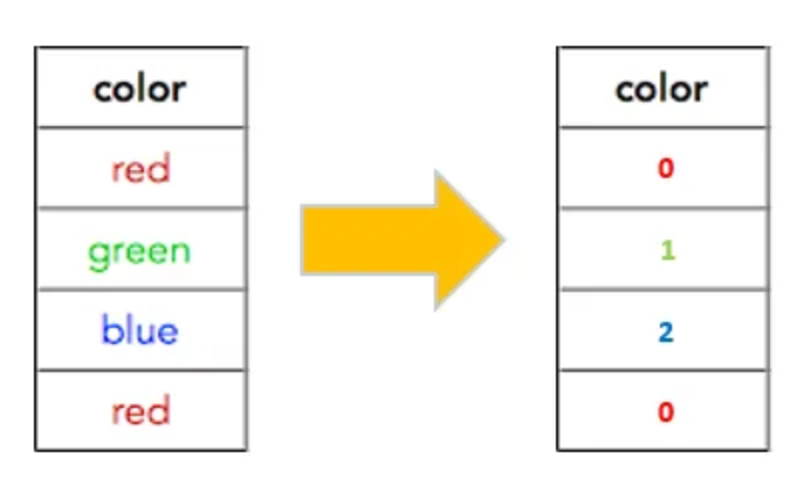

In [11]:
# ============================================================================
# CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# ============================================================================

print("CODIFICACIÓN DE VARIABLES CATEGÓRICAS")
print("="*80 + "\n")

# Crear diccionario para almacenar los encoders (útil para producción)
label_encoders = {}

# Variables a codificar (Info pre-vuelo)
variables_categoricas = ['AIRLINE', 'ORIGIN', 'DEST']

for var in variables_categoricas:
    le = LabelEncoder()
    df_limpio[f'{var}_ENCODED'] = le.fit_transform(df_limpio[var])
    label_encoders[var] = le

    print(f"{var}:")
    print(f"  Categorías únicas: {df_limpio[var].nunique()}")
    print(f"  Ejemplo mapeo: {dict(list(zip(le.classes_[:5], le.transform(le.classes_[:5]))))}...")
    print()

print("Variables codificadas creadas:")
for var in variables_categoricas:
    print(f"  - {var}_ENCODED")

CODIFICACIÓN DE VARIABLES CATEGÓRICAS

AIRLINE:
  Categorías únicas: 18
  Ejemplo mapeo: {'Alaska Airlines Inc.': np.int64(0), 'Allegiant Air': np.int64(1), 'American Airlines Inc.': np.int64(2), 'Delta Air Lines Inc.': np.int64(3), 'Endeavor Air Inc.': np.int64(4)}...

ORIGIN:
  Categorías únicas: 380
  Ejemplo mapeo: {'ABE': np.int64(0), 'ABI': np.int64(1), 'ABQ': np.int64(2), 'ABR': np.int64(3), 'ABY': np.int64(4)}...

DEST:
  Categorías únicas: 380
  Ejemplo mapeo: {'ABE': np.int64(0), 'ABI': np.int64(1), 'ABQ': np.int64(2), 'ABR': np.int64(3), 'ABY': np.int64(4)}...

Variables codificadas creadas:
  - AIRLINE_ENCODED
  - ORIGIN_ENCODED
  - DEST_ENCODED


### **5.4. Features Experimentales: WEATHER_RISK y BAD_WEATHER**

In [12]:
# ============================================================================
# FEATURE EXPERIMENTAL: RIESGO CLIMÁTICO HISTÓRICO
# ============================================================================

# Ordenar por fecha y origen
df_limpio = df_limpio.sort_values(['ORIGIN', 'FL_DATE'])

# WEATHER_RISK: Hubo retrasos por clima en los últimos 14 días en este aeropuerto?
# NOTA: Usa shift(1) para evitar data leakage (información del día actual
print("\nCreando FEATURES EXPERIMENTALES...")
df_limpio['WEATHER_RISK'] = (df_limpio
        .groupby('ORIGIN')['DELAY_DUE_WEATHER']
        .shift(1)    # Excluye el vuelo actual
        .rolling(14, min_periods=1)
        .max()         # hubo al menos un evento?
        .fillna(0)
        .astype(int)
)

df_limpio['BAD_WEATHER'] = (df_limpio['DELAY_DUE_WEATHER'] > 5).astype(int)

print("NOTA: Estas features son experimentales - requiere validación de disponibilidad en producción")


Creando FEATURES EXPERIMENTALES...
NOTA: Estas features son experimentales - requiere validación de disponibilidad en producción


<a id="6-división-de-datos-y-balanceo-de-clases"></a>
## **6. División de Datos y Balanceo de Clases**

### **6.1. Objetivo**
Dividir el dataset en conjuntos de entrenamiento y prueba, y balancear las clases para evitar sesgo hacia la clase mayoritaria.


### **6.2. Definición de Conjuntos de Features**

Definimos los conjuntos de características que usaremos para entrenar el modelo.

#### Criterios de Selección

1. **Disponibilidad pre-vuelo**: Solo información conocida antes del despegue
2. **Relevancia**: Variables con correlación significativa o lógica operacional
3. **No-leakage**: Excluir variables que contengan información del resultado

**Conjunto Base (7 features - SIN data leakage):**
- Temporales: `MONTH`, `DAY`, `CRS_DEP_TIME`
- Operacionales: `DISTANCE`, `CRS_ELAPSED_TIME`
- Categoricas: `AIRLINE_ENCODED`, `ORIGIN_ENCODED`, `DEST_ENCODED`

In [13]:
# Conjunto BASE (7 features - MVP mínimo)
FEATURES_BASE = [
    'AIRLINE_ENCODED',
    'MONTH', 'DAY',
    'CRS_DEP_TIME',
    'ORIGIN_ENCODED',
    'DEST_ENCODED',
    'DISTANCE'
]

# Conjunto FULL (11 features)
FEATURES_FULL = FEATURES_BASE + [
    'CRS_ARR_TIME', 'CRS_ELAPSED_TIME',
    'IS_PEAK_DAY','IS_HOLIDAY'
]

# Conjunto EXTRA (15 features - Recomendado para producción)
FEATURES_EXTRA = FEATURES_FULL + [
    'DAY_WEEK','FL_NUMBER', 'DOT_CODE','IS_WEEKEND',
    ]

# Conjunto CLIMA (17 features - Incluye WEATHER_RISK, BAD_WEATHER)
FEATURES_BWHA = FEATURES_EXTRA + ['BAD_WEATHER','WEATHER_RISK']

# Conjunto DELAY (20 features - Incluye DATA LEAKAGE)
FEATURES_DELAY = FEATURES_EXTRA + [
    'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS',
    'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT'
]

TARGET = 'TARG_DESP'

print(f"Features Base:      {len(FEATURES_BASE)} variables")
print(f"Features Completo:  {len(FEATURES_FULL)} variables")
print(f"Features Extras:    {len(FEATURES_EXTRA)} variables")
print(f"Features Mal Clima: {len(FEATURES_BWHA)} variables")
print(f"Features Delay:     {len(FEATURES_DELAY)} variables")
print(f"Target:             {TARGET}")

Features Base:      7 variables
Features Completo:  11 variables
Features Extras:    15 variables
Features Mal Clima: 17 variables
Features Delay:     20 variables
Target:             TARG_DESP


### **6.3. División de Datos: Entrenamiento y Prueba**

Dividimos el dataset en dos conjuntos:

- **Train (80%)**: Para entrenar el modelo
- **Test (20%)**: Para evaluar el desempeño en datos no vistos

> **NOTA IMPORTANTE**  
> El conjunto de prueba NO se usa durante el entrenamiento. Esto permite evaluar cómo el modelo generaliza a datos nuevos (situación real de producción).

#### Estratificación

Usamos `stratify` para mantener la misma proporción de clases (PUNTUAL/RETRASADO) en ambos conjuntos.

In [14]:
# -------------------------------------
# 1. FEATURES_BASE (7 features - Modelo productivo básico)
# -------------------------------------

# Separar features (X) y target (y)
print("1. Procesando FEATURES_BASE...")
X_base = df_limpio[FEATURES_BASE]
y_base = df_limpio[TARGET]

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base, y_base, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_base
)
print("(Division Completada)")

1. Procesando FEATURES_BASE...
(Division Completada)


In [15]:
# -------------------------------------
# 2. FEATURES_FULL (14 features - Modelo completo)
# -------------------------------------
print("2. Procesando FEATURES_FULL...")
X_full = df_limpio[FEATURES_FULL]
y_full = df_limpio[TARGET]

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_full
)
print("(Division Completada)")

2. Procesando FEATURES_FULL...
(Division Completada)


In [16]:
# -------------------------------------
# 3. FEATURES_EXTRA (19 features - Modelo experimental con variables dudosas)
# -------------------------------------
print("3. Procesando FEATURES_EXTRA...")
X_extra = df_limpio[FEATURES_EXTRA]
y_extra = df_limpio[TARGET]

X_train_extra, X_test_extra, y_train_extra, y_test_extra = train_test_split(
    X_extra, y_extra, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_extra
)
print("(Division Completada)")

3. Procesando FEATURES_EXTRA...
(Division Completada)


In [17]:
# -------------------------------------
# 4. FEATURES_BWHA (20 features - Modelo con variable de mal clima)
# -------------------------------------
print("4. Procesando FEATURES_BWHA...")
X_bwha = df_limpio[FEATURES_BWHA]
y_bwha = df_limpio[TARGET]

X_train_bwha, X_test_bwha, y_train_bwha, y_test_bwha = train_test_split(
    X_bwha, y_bwha, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_bwha
)
print("(Division Completada)")

4. Procesando FEATURES_BWHA...
(Division Completada)


In [18]:
# -----------------------------------
# 5. FEATURES_DELAY (24 features - Modelo con data leakage - SOLO EXPERIMENTAL)
# -----------------------------------
print("5. Procesando FEATURES_DELAY...")
X_delay = df_limpio[FEATURES_DELAY]
y_delay = df_limpio[TARGET]

X_train_delay, X_test_delay, y_train_delay, y_test_delay = train_test_split(
    X_delay, y_delay, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_delay
)
print("(Division Completada)")

5. Procesando FEATURES_DELAY...
(Division Completada)


### **6.4. Balanceo por Undersampling**

**Ventajas del Undersampling:**
- Balancea perfectamente las clases (50%-50%)
- Reduce el tiempo de entrenamiento
- Mejora la capacidad del modelo para detectar retrasos
- Evita el sesgo hacia la clase mayoritaria

**Desventajas:**
- Se pierde información de la clase mayoritaria
- Dataset final más pequeño

> **IMPORTANTE**  
> El undersampling se aplica **SOLO** al conjunto de entrenamiento. El conjunto de prueba mantiene su distribución original para evaluar el desempeño real del modelo.

#### **6.4.1. Balanceo (BASE)**

In [19]:
print("APLICACIÓN DE UNDERSAMPLING")
print("="*80 + "\n")

print("1. Balanceando FEATURES_BASE...\n")
# Unir temporalmente para balanceo
df_train_temp_base = pd.concat([X_train_base, y_train_base], axis=1)

# Separar clases en el conjunto de entrenamiento
df_mayoritaria_base = df_train_temp_base[df_train_temp_base[TARGET] == 0]
df_minoritaria_base = df_train_temp_base[df_train_temp_base[TARGET] == 1]

print("Distribución ANTES del balanceo:")
print(f"Total registros train: {len(y_train_base):,}")
print(f" - Clase mayoritaria (0):   {len(df_mayoritaria_base):,} {(len(df_mayoritaria_base) / len(y_train_base) * 100):>5.2f}%")
print(f" - Clase minoritaria (1): {len(df_minoritaria_base):,} {(len(df_minoritaria_base) / len(y_train_base) * 100):>5.2f}%")
print(f" - Ratio desbalance: 1:{len(df_mayoritaria_base)/len(df_minoritaria_base):.2f}")

diferencia = len(df_mayoritaria_base) - len(df_minoritaria_base)
print(f"Diferencia absoluta: {diferencia:,} registros")

# -----------------------------------
# 1. Balanceo FEATURES_BASE
# -----------------------------------

# Undersampling: reducir la clase mayoritaria
df_mayoritaria_base_under = resample(
    df_mayoritaria_base, replace=False,
    n_samples=len(df_minoritaria_base), random_state=RANDOM_STATE
)

# Combinar ambas clases (Balanceadas)
# Mezclar aleatoriamente (42)
df_train_bal_base = pd.concat([df_mayoritaria_base_under, df_minoritaria_base])
df_train_bal_base = df_train_bal_base.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

# Separar nuevamente X e y
X_train_bal_base = df_train_bal_base[FEATURES_BASE]
y_train_bal_base = df_train_bal_base[TARGET]

print("\nDistribución DESPUES del balanceo:")
print(f" - Clase mayoritaria: {len(df_mayoritaria_base_under):,} {(len(df_mayoritaria_base_under) / len(y_train_bal_base) * 100):>5.2f}%")
print(f" - Clase minoritaria: {len(df_minoritaria_base):,} {(len(df_minoritaria_base) / len(y_train_bal_base) * 100):>5.2f}%")
print(f" - Ratio balanceado: 1:{len(df_mayoritaria_base_under)/len(df_minoritaria_base):.2f}")
print(f"Dataset balanceado: {len(y_train_bal_base):,} registros")
print(f"\nTest set: {len(X_test_base):,} registros (sin modificar)")
print("Balanceo Completad (FEATURES_BASE)")

APLICACIÓN DE UNDERSAMPLING

1. Balanceando FEATURES_BASE...

Distribución ANTES del balanceo:
Total registros train: 2,331,041
 - Clase mayoritaria (0):   1,922,444 82.47%
 - Clase minoritaria (1): 408,597 17.53%
 - Ratio desbalance: 1:4.70
Diferencia absoluta: 1,513,847 registros

Distribución DESPUES del balanceo:
 - Clase mayoritaria: 408,597 50.00%
 - Clase minoritaria: 408,597 50.00%
 - Ratio balanceado: 1:1.00
Dataset balanceado: 817,194 registros

Test set: 582,761 registros (sin modificar)
Balanceo Completad (FEATURES_BASE)


#### **6.4.2. Balanceo (FULL)**

In [20]:
# -----------------------------------
# 2. Balanceo FEATURES_FULL
# -----------------------------------
print("2. Balanceando FEATURES_FULL...")
# Separar clases en el conjunto de entrenamiento
df_train_temp_full = pd.concat([X_train_full, y_train_full], axis=1)
df_mayoritaria_full = df_train_temp_full[df_train_temp_full[TARGET] == 0]
df_minoritaria_full = df_train_temp_full[df_train_temp_full[TARGET] == 1]

# Undersampling: reducir la clase mayoritaria
df_mayoritaria_under_full = resample(
    df_mayoritaria_full, replace=False,
    n_samples=len(df_minoritaria_full), random_state=RANDOM_STATE
)

# Combinar ambas clases (Balanceadas)
df_train_bal_full = pd.concat([df_mayoritaria_under_full, df_minoritaria_full])
# Mezclar aleatoriamente
df_train_bal_full = df_train_bal_full.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

X_train_bal_full = df_train_bal_full[FEATURES_FULL]
y_train_bal_full = df_train_bal_full[TARGET]
print("Balanceo Completado (FEATURES_FULL)")

2. Balanceando FEATURES_FULL...
Balanceo Completado (FEATURES_FULL)


#### **6.4.3. Balanceo (EXTRA)**

In [21]:
# -----------------------------------
# 3. Balanceo FEATURES_EXTRA
# -----------------------------------
print("3. Balanceando FEATURES_EXTRA...")
df_train_temp_extra = pd.concat([X_train_extra, y_train_extra], axis=1)
df_mayoritaria_extra = df_train_temp_extra[df_train_temp_extra[TARGET] == 0]
df_minoritaria_extra = df_train_temp_extra[df_train_temp_extra[TARGET] == 1]

df_mayoritaria_under_extra = resample(
    df_mayoritaria_extra, replace=False,
    n_samples=len(df_minoritaria_extra), random_state=RANDOM_STATE
)

df_train_bal_extra = pd.concat([df_mayoritaria_under_extra, df_minoritaria_extra])
df_train_bal_extra = df_train_bal_extra.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

X_train_bal_extra = df_train_bal_extra[FEATURES_EXTRA]
y_train_bal_extra = df_train_bal_extra[TARGET]
print("Balanceo Completad (FEATURES_EXTRA)")

3. Balanceando FEATURES_EXTRA...
Balanceo Completad (FEATURES_EXTRA)


#### **6.4.4. Balanceo (BWHA)**

In [22]:
# -----------------------hola--------
# 4. Balanceo FEATURES_BWHA
# -----------------------------------
print("4. Balanceando FEATURES_BWHA...")
df_train_temp_bwha = pd.concat([X_train_bwha, y_train_bwha], axis=1)
df_mayoritaria_bwha = df_train_temp_bwha[df_train_temp_bwha[TARGET] == 0]
df_minoritaria_bwha = df_train_temp_bwha[df_train_temp_bwha[TARGET] == 1]

df_mayoritaria_under_bwha = resample(
    df_mayoritaria_bwha, replace=False,
    n_samples=len(df_minoritaria_bwha), random_state=RANDOM_STATE
)

df_train_bal_bwha = pd.concat([df_mayoritaria_under_bwha, df_minoritaria_bwha])
df_train_bal_bwha = df_train_bal_bwha.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

X_train_bal_bwha = df_train_bal_bwha[FEATURES_BWHA]
y_train_bal_bwha = df_train_bal_bwha[TARGET]
print("Balanceo Completado (FEATURES_BWHA)")


4. Balanceando FEATURES_BWHA...
Balanceo Completado (FEATURES_BWHA)


#### **6.4.5. Balanceo (DELAY)**

In [23]:
# -----------------------------------
# 5. Balanceo FEATURES_DELAY (DATA LEAKAGE)
# -----------------------------------
print("5. Balanceando FEATURES_DELAY (DATA LEAKAGE)...")
df_train_temp_delay = pd.concat([X_train_delay, y_train_delay], axis=1)
df_mayoritaria_delay = df_train_temp_delay[df_train_temp_delay[TARGET] == 0]
df_minoritaria_delay = df_train_temp_delay[df_train_temp_delay[TARGET] == 1]

df_mayoritaria_under_delay = resample(
    df_mayoritaria_delay, replace=False,
    n_samples=len(df_minoritaria_delay), random_state=RANDOM_STATE
)

df_train_bal_delay = pd.concat([df_mayoritaria_under_delay, df_minoritaria_delay])
df_train_bal_delay = df_train_bal_delay.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

X_train_bal_delay = df_train_bal_delay[FEATURES_DELAY]
y_train_bal_delay = df_train_bal_delay[TARGET]
print("Balanceo Completado (FEATURES_DELAY)")

5. Balanceando FEATURES_DELAY (DATA LEAKAGE)...
Balanceo Completado (FEATURES_DELAY)


### **6.5. Justificación Técnica**
- **Estratificación:** Mantiene proporción original de clases en test (escenario real)
- **Undersampling:** Solución óptima para datasets grandes (>2M registros)
- **Balance perfecto:** 50/50 elimina sesgo hacia clase mayoritaria sin crear muestras sintéticas

<a id="7-definición-de-conjuntos-de-features"></a>
## **7. Definición de Conjuntos de Features**

### **7.1. Resumen de Conjuntos para Experimentación**

In [24]:
# ============================================================================
# RESUMEN DE CONJUNTOS PREPARADOS
# ============================================================================
print("RESUMEN DE CONJUNTOS DE DATOS PREPARADOS")
print("="*80 + "\n")

resumen_datos = pd.DataFrame({
    'Conjunto': ['BASE', 'FULL', 'EXTRA', 'BWHA', 'DELAY'],
    'N° Features': [
        len(FEATURES_BASE),
        len(FEATURES_FULL),
        len(FEATURES_EXTRA),
        len(FEATURES_BWHA),
        len(FEATURES_DELAY)
    ],
    'Train Original': [
        len(X_train_base),
        len(X_train_full),
        len(X_train_extra),
        len(X_train_bwha),
        len(X_train_delay)
    ],
    'Train Balanceado': [
        len(X_train_bal_base),
        len(X_train_bal_full),
        len(X_train_bal_extra),
        len(X_train_bal_bwha),
        len(X_train_bal_delay)
    ],
    'Test': [
        len(X_test_base),
        len(X_test_full),
        len(X_test_extra),
        len(X_test_bwha),
        len(X_test_delay)
    ],
    'Válido Producción': ['Sí', 'Sí', 'Evaluar', 'Evaluar', 'NO (leakage)']
})
display(resumen_datos)

print("\nIMPORTANTE:")
print("- Conjuntos TEST mantienen distribución original (desbalanceada)")
print("- FEATURES_DELAY incluye variables post-vuelo (solo experimental)")
print("- Todos los conjuntos usan random_state=42 para reproducibilidad")

RESUMEN DE CONJUNTOS DE DATOS PREPARADOS



,Conjunto,N° Features,Train Original,Train Balanceado,Test,Válido Producción
0,BASE,7,2331041,817194,582761,Sí
1,FULL,11,2331041,817194,582761,Sí
2,EXTRA,15,2331041,817194,582761,Evaluar
3,BWHA,17,2331041,817194,582761,Evaluar
4,DELAY,20,2331041,817194,582761,NO (leakage)



IMPORTANTE:
- Conjuntos TEST mantienen distribución original (desbalanceada)
- FEATURES_DELAY incluye variables post-vuelo (solo experimental)
- Todos los conjuntos usan random_state=42 para reproducibilidad


### **7.2. Matriz de Correlación (Features Numéricas)**

In [25]:
# ============================================================================
# ANÁLISIS DE CORRELACIÓN
# ============================================================================
print("Analizando CORRELACIONES ENTRE FEATURES...")

# Seleccionar solo features numéricas para correlación
features_numericas = [f for f in FEATURES_EXTRA if df_limpio[f].dtype in ['int32', 'float32', 'int64', 'float64']]

if len(features_numericas) > 1:
    corr_matrix = df_limpio[features_numericas].corr()

    # Identificar correlaciones altas (>0.7)
    high_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > 0.7:
                high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

    if high_corr:
        print(f"CORRELACIONES ALTAS DETECTADAS (>0.7):")
        for feat1, feat2, corr in high_corr:
            print(f"   - {feat1} <-> {feat2}: {corr:.3f}")
    else:
        print("No se detectaron correlaciones problemáticas (>0.7)")
else:
    print("Insuficientes features numéricas para análisis de correlación")

Analizando CORRELACIONES ENTRE FEATURES...
CORRELACIONES ALTAS DETECTADAS (>0.7):
   - CRS_ARR_TIME <-> CRS_DEP_TIME: 0.702
   - CRS_ELAPSED_TIME <-> DISTANCE: 0.983
   - IS_WEEKEND <-> DAY_WEEK: 0.784


<a id="8-modelado-predictivo-y-experimentacion"></a>
## **8. Modelado Predictivo y Experimentacion**

### **8.1. Objetivo**
Entrenar multiples modelos RandomForest con diferentes configuraciones para identificar la mejor solucion

### **¿Por qué RandomForest?**

**Ventajas para este problema:**
- Maneja bien variables categóricas codificadas
- Robusto ante multicolinealidad
- Proporciona importancia de features
- No requiere escalado de variables
- Resistente al overfitting con parámetros adecuados

### **Estrategia de Modelado**

| Aspecto | Modelo Base | Modelo Full | Modelo Extra | Modelo BWHA | Modelo DELAY (Leakage) | Modelo Optimizado (GridSearch - RFE) |
|---------|-------------|-------------|--------------|-------------|------------------------|----------------------------|
| **Propósito** | MVP rápido - Línea base | Balance features/rendimiento | Features adicionales dudosas | Incluye clima (experimental) | Data leakage explícito | Máximo rendimiento - Feature selection |
| **Tiempo Entrenamiento** | ~35 segundos | ~45 segundos | ~55 segundos | ~60 segundos | ~65 segundos | 1h~90 segundos |
| **Features** | 7 | 13 | 17 | 18 | 22 | 5-14 |
| **Hiperparámetros** | Recomendados  | Recomendados | Recomendados | Recomendados | Recomendados | Optimizados (n_est=200) |
| **Uso Recomendado** | Prototipo inicial | Validación intermedia | Análisis adicionales | Investigación clima | Solo experimental | **Producción final** |

### **8.2 Modelo Base: (Parámetros Recomendados)**

#### **8.2.1. Entrenamiento del Modelo Base**

Modelo con parámetros equilibrados entre rendimiento y velocidad.

**Parámetros seleccionados:**
- `n_estimators=100`: Número de árboles (balance velocidad/precisión)
- `max_depth=15`: Profundidad máxima (evita overfitting)
- `min_samples_split=20`: Mínimo de muestras para dividir nodo
- `min_samples_leaf=10`: Mínimo de muestras en hoja
- `random_state=42`: Reproducibilidad
- `n_jobs=-1`: Usar todos los núcleos del CPU


In [26]:
# -----------------------------------
# 1. MODELO BASE
# -----------------------------------
modelo_base = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)
print("Creacion del MODELO BASE (Completado)")

# Inicio contador
inicio = time()
print("Entrenando MODELO BASE...")
# Entrenamos
modelo_base.fit(X_train_bal_base, y_train_bal_base)
# Final registro contador
tiempo_base = time() - inicio
print(f"Entrenamiento completado en {tiempo_base:.2f} segundos")

Creacion del MODELO BASE (Completado)
Entrenando MODELO BASE...
Entrenamiento completado en 110.57 segundos


#### **8.2.2. Evaluación del Modelo Base**

In [27]:
# Evaluacion modelo
y_pred_base = modelo_base.predict(X_test_base)
y_pred_proba_base = modelo_base.predict_proba(X_test_base)[:, 1]

# Crear variables ROC-AUC
acc_base = accuracy_score(y_test_base, y_pred_base)
auc_base = roc_auc_score(y_test_base, y_pred_proba_base)

print("\nReporte de Clasificación (Modelo Base):")
print(classification_report(y_test_base, y_pred_base,
                           target_names=['PUNTUAL', 'RETRASADO'],
                           digits=4))

print(f"\nMétricas en conjunto de prueba: Accuracy: {acc_base:.4f} | ROC-AUC: {auc_base:.4f}")

# Importancia de features
importancias_base = pd.DataFrame({
    'Feature': FEATURES_BASE,
    'Importancia': modelo_base.feature_importances_
}).sort_values('Importancia', ascending=False)

print("\nImportancia de Features:\n")
display(importancias_base)


Reporte de Clasificación (Modelo Base):
              precision    recall  f1-score   support

     PUNTUAL     0.8876    0.6349    0.7402    480612
   RETRASADO     0.2657    0.6217    0.3723    102149

    accuracy                         0.6326    582761
   macro avg     0.5766    0.6283    0.5563    582761
weighted avg     0.7786    0.6326    0.6758    582761


Métricas en conjunto de prueba: Accuracy: 0.6326 | ROC-AUC: 0.6780

Importancia de Features:



,Feature,Importancia
3,CRS_DEP_TIME,0.44
6,DISTANCE,0.11
0,AIRLINE_ENCODED,0.11
1,MONTH,0.10
4,ORIGIN_ENCODED,0.08
2,DAY,0.08
5,DEST_ENCODED,0.07


### **8.3. Matriz de Confusión (Funcion)**
Visualizamos los tipos de errores que comete el modelo.

**Componentes:**
- **Verdaderos Negativos (TN):** Predijo PUNTUAL, fue PUNTUAL
- **Falsos Positivos (FP):** Predijo RETRASADO, fue PUNTUAL
- **Falsos Negativos (FN):** Predijo PUNTUAL, fue RETRASADO
- **Verdaderos Positivos (TP):** Predijo RETRASADO, fue RETRASADO

In [28]:
def plot_confusion_matrix(
    y_real,
    y_pred,
    title,
    labels=[0, 1],
    class_names=['PUNTUAL (0)', 'RETRASADO (1)'],
    cmap='Blues',
    figsize=(8, 6)
):
    """
    Grafica una matriz de confusión binaria con:
    - TN, FP, FN, TP
    - valores absolutos
    - porcentajes por fila
    """

    # 1. Cálculo de la matriz de confusión
    cm = confusion_matrix(y_real, y_pred, labels=labels)

    # 2. Extracción de valores
    tn, fp, fn, tp = cm.ravel()

    # 3. Porcentajes por fila
    total = np.sum(cm)
    pct_tn, pct_fp = tn/total*100, fp/total*100
    pct_fn, pct_tp = fn/total*100, tp/total*100

    # 4. Etiquetas internas (texto dentro de los cuadros)
    labels_cuadros = [
        [f"TN\n{tn}\n({pct_tn:.1f}%)", f"FP\n{fp}\n({pct_fp:.1f}%)"],
        [f"FN\n{fn}\n({pct_fn:.1f}%)", f"TP\n{tp}\n({pct_tp:.1f}%)"]
    ]

    # 5. Gráfico
    plt.figure(figsize=figsize)
    ax = sns.heatmap(
        cm,
        annot=labels_cuadros,
        fmt="",
        cmap=cmap,
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=True
    )

    # Texto en negrita
    for text in ax.texts:
        text.set_weight('bold')

    # Etiquetas y título
    plt.xlabel(f'Predicción del modelo')
    plt.ylabel('Valor real')
    plt.title(f"Matriz de Confusión - {title}")

    plt.show()

    return cm

#### **8.2.3. Matriz del Modelo Base**

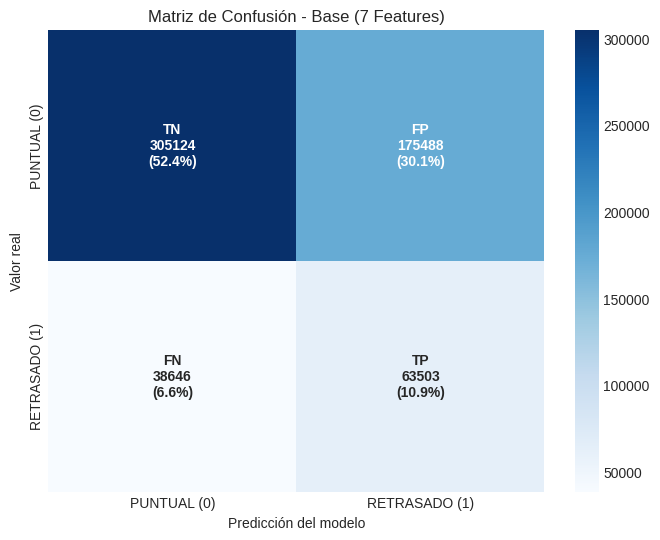

In [29]:
cm_base = plot_confusion_matrix(
    y_real=y_test_base,
    y_pred=y_pred_base,
    title='Base (7 Features)'
)

### **8.4. Modelo FULL**

#### **8.4.1. Entrenamiento del Modelo Full**

In [30]:
# -----------------------------------
# 2. MODELO FULL
# -----------------------------------
modelo_full = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)
print("Creacion del MODELO FULL (Completado)")
inicio = time()
print("Entrenando MODELO FULL...")
modelo_full.fit(X_train_bal_full, y_train_bal_full)
tiempo_full = time() - inicio
print(f"Entrenamiento completado en {tiempo_full:.2f} segundos")

Creacion del MODELO FULL (Completado)
Entrenando MODELO FULL...
Entrenamiento completado en 150.43 segundos


#### **8.4.2. Evaluacion del Modelo Full**

In [31]:
#Predecimos
y_pred_full = modelo_full.predict(X_test_full)
y_pred_proba_full = modelo_full.predict_proba(X_test_full)[:, 1]

acc_full = accuracy_score(y_test_full, y_pred_full)
auc_full = roc_auc_score(y_test_full, y_pred_proba_full)

print("\nReporte de Clasificación (MODELO FULL):")
print(classification_report(y_test_full, y_pred_full,
                          target_names=['PUNTUAL', 'RETRASADO'], digits=4))

print(f"\nMétricas en conjunto de prueba: Accuracy: {acc_full:.4f} | ROC-AUC: {auc_full:.4f}")

importancias_full = pd.DataFrame({
    'Feature': FEATURES_FULL,
    'Importancia': modelo_full.feature_importances_
}).sort_values('Importancia', ascending=False)

print("\nImportancia de Features:\n")
display(importancias_full.head(10))


Reporte de Clasificación (MODELO FULL):
              precision    recall  f1-score   support

     PUNTUAL     0.8863    0.6355    0.7402    480612
   RETRASADO     0.2644    0.6163    0.3700    102149

    accuracy                         0.6321    582761
   macro avg     0.5753    0.6259    0.5551    582761
weighted avg     0.7773    0.6321    0.6753    582761


Métricas en conjunto de prueba: Accuracy: 0.6321 | ROC-AUC: 0.6760

Importancia de Features:



,Feature,Importancia
3,CRS_DEP_TIME,0.27
7,CRS_ARR_TIME,0.22
0,AIRLINE_ENCODED,0.10
1,MONTH,0.08
6,DISTANCE,0.08
8,CRS_ELAPSED_TIME,0.07
4,ORIGIN_ENCODED,0.06
2,DAY,0.06
5,DEST_ENCODED,0.05
9,IS_PEAK_DAY,0.00


#### **8.4.3. Matriz del Modelo Full**

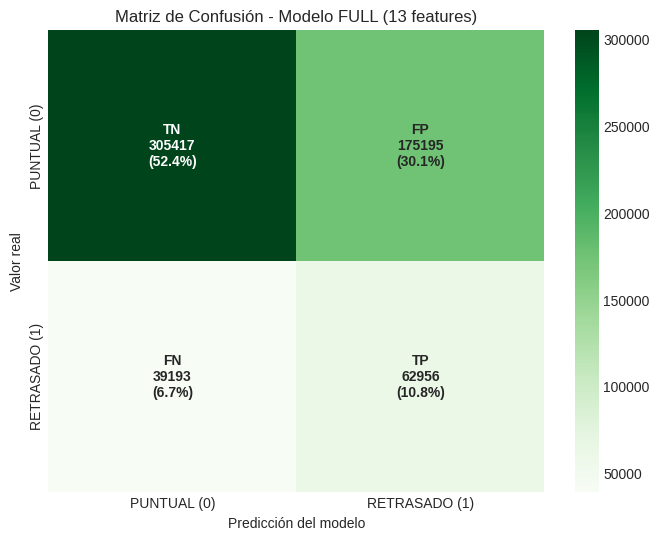

In [32]:
cm_full = plot_confusion_matrix(
    y_real=y_test_full,
    y_pred=y_pred_full,
    title='Modelo FULL (13 features)',
    cmap='Greens'
)

### **8.5. Modelo EXTRA**

#### **8.5.1. Entrenamiento del Modelo Extra**

In [33]:
# -----------------------------------
# 3. MODELO EXTRA
# -----------------------------------
modelo_extra = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)
print("Creacion del MODELO EXTRA (Completado)")

inicio = time()
print("Entrenando MODELO EXTRA...")
modelo_extra.fit(X_train_bal_extra, y_train_bal_extra)
tiempo_extra = time() - inicio
print(f"Entrenamiento completado en {tiempo_extra:.2f} segundos")

Creacion del MODELO EXTRA (Completado)
Entrenando MODELO EXTRA...
Entrenamiento completado en 143.13 segundos


#### **8.5.2. Evaluacion del Modelo Extra**

In [34]:
y_pred_extra = modelo_extra.predict(X_test_extra)
y_pred_proba_extra = modelo_extra.predict_proba(X_test_extra)[:, 1]

acc_extra = accuracy_score(y_test_extra, y_pred_extra)
auc_extra = roc_auc_score(y_test_extra, y_pred_proba_extra)
print("\nReporte de Clasificación (MODELO_EXTRA):")
print(classification_report(y_test_extra, y_pred_extra,
                          target_names=['PUNTUAL', 'RETRASADO'], digits=4))

print(f"\nMétricas en conjunto de prueba: Accuracy: {acc_extra:.4f} | ROC-AUC: {auc_extra:.4f}")

# 3. Importancias EXTRA
importancias_extra = pd.DataFrame({
    'Feature': FEATURES_EXTRA,
    'Importancia': modelo_extra.feature_importances_
}).sort_values('Importancia', ascending=False)

print("\nImportancia de Features:\n")
display(importancias_extra.head(10))


Reporte de Clasificación (MODELO_EXTRA):
              precision    recall  f1-score   support

     PUNTUAL     0.8883    0.6405    0.7443    480612
   RETRASADO     0.2685    0.6210    0.3749    102149

    accuracy                         0.6370    582761
   macro avg     0.5784    0.6307    0.5596    582761
weighted avg     0.7796    0.6370    0.6795    582761


Métricas en conjunto de prueba: Accuracy: 0.6370 | ROC-AUC: 0.6807

Importancia de Features:



,Feature,Importancia
3,CRS_DEP_TIME,0.26
7,CRS_ARR_TIME,0.20
12,FL_NUMBER,0.08
1,MONTH,0.07
13,DOT_CODE,0.06
6,DISTANCE,0.06
8,CRS_ELAPSED_TIME,0.06
4,ORIGIN_ENCODED,0.05
0,AIRLINE_ENCODED,0.05
2,DAY,0.05


#### **8.5.3. Matriz del Modelo Extra**

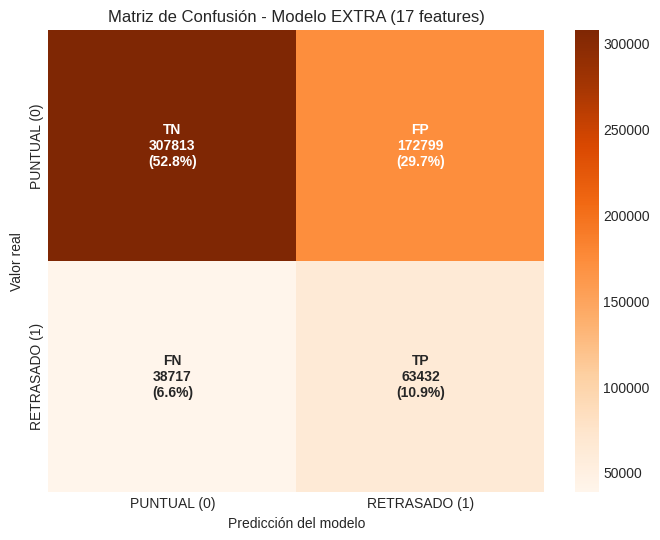

In [35]:
cm_extra = plot_confusion_matrix(
    y_real=y_test_extra,
    y_pred=y_pred_extra,
    title='Modelo EXTRA (17 features)',
    cmap='Oranges'
)

### **8.6. Modelo Mal clima**

#### **8.6.1. Entrenamiento del Modelo Mal Clima**

In [36]:
# -----------------------------------
# 4. MODELO BWHA (Bad Weather)
# -----------------------------------
modelo_bwha = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)
print("Creacion del MODELO BWHA (Completado)")

inicio = time()
print("Entrenando MODELO BWHA...")
modelo_bwha.fit(X_train_bal_bwha, y_train_bal_bwha)
tiempo_bwha = time() - inicio
print(f"Entrenamiento completado en {tiempo_bwha:.2f} segundos")

Creacion del MODELO BWHA (Completado)
Entrenando MODELO BWHA...
Entrenamiento completado en 170.13 segundos


#### **8.6.1. Evaluacion del Modelo Mal Clima**

In [37]:
y_pred_bwha = modelo_bwha.predict(X_test_bwha)
y_pred_proba_bwha = modelo_bwha.predict_proba(X_test_bwha)[:, 1]

acc_bwha = accuracy_score(y_test_bwha, y_pred_bwha)
auc_bwha = roc_auc_score(y_test_bwha, y_pred_proba_bwha)

print("\nReporte de Clasificación (Modelo BWHA):")
print(classification_report(y_test_bwha, y_pred_bwha,
                          target_names=['PUNTUAL', 'RETRASADO'], digits=4))

print(f"\nMétricas en conjunto de prueba: Accuracy: {acc_bwha:.4f} | ROC-AUC: {auc_bwha:.4f}")

# 4. Importancias BWHA
importancias_bwha = pd.DataFrame({
    'Feature': FEATURES_BWHA,
    'Importancia': modelo_bwha.feature_importances_
}).sort_values('Importancia', ascending=False)

print("\nImportancia de Features:\n")
display(importancias_bwha.head(10))


Reporte de Clasificación (Modelo BWHA):
              precision    recall  f1-score   support

     PUNTUAL     0.8906    0.6788    0.7704    480612
   RETRASADO     0.2868    0.6078    0.3897    102149

    accuracy                         0.6664    582761
   macro avg     0.5887    0.6433    0.5801    582761
weighted avg     0.7848    0.6664    0.7037    582761


Métricas en conjunto de prueba: Accuracy: 0.6664 | ROC-AUC: 0.6996

Importancia de Features:



,Feature,Importancia
3,CRS_DEP_TIME,0.24
7,CRS_ARR_TIME,0.15
15,BAD_WEATHER,0.14
12,FL_NUMBER,0.06
13,DOT_CODE,0.06
16,WEATHER_RISK,0.05
1,MONTH,0.05
0,AIRLINE_ENCODED,0.04
6,DISTANCE,0.04
8,CRS_ELAPSED_TIME,0.04


#### **8.6.3. Matriz del Modelo Mal clima**

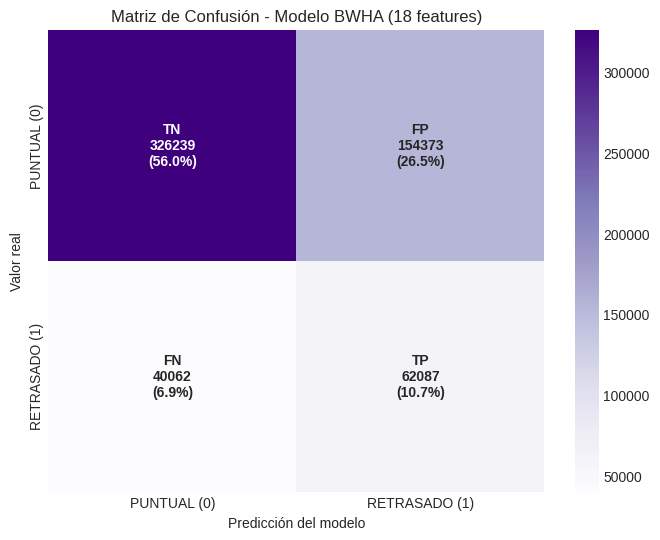

In [38]:
cm_bwha = plot_confusion_matrix(
    y_real=y_test_bwha,
    y_pred=y_pred_bwha,
    title='Modelo BWHA (18 features)',
    cmap='Purples'
)

### **8.7. Modelo DELAY_DUE: (Features Extendidas)**

> **ADVERTENCIA**  
> Este experimento incluye variables `DELAY_DUE_*` que solo algunas se conocen DESPUES del vuelo. Es puramente exploratorio para medir su impacto. **NO es valido para produccion.**

**Objetivo:** Cuantificar cuanto mejoran las metricas con informacion post-vuelo.

#### **8.7.1. Entrenamiento del Modelo DELAY_DUE**

In [39]:
# -----------------------------------
# 5. MODELO DELAY
# -----------------------------------
modelo_delay = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)
print("Creacion del modelo DELAY (completado)")

# Inicio contador
inicio = time()
print("Iniciando entrenamiento del modelo DELAY...")
# Entrenamos
modelo_delay.fit(X_train_bal_delay, y_train_bal_delay)
# Final registro contador
tiempo_delay = time() - inicio
print(f"Tiempo de entrenamiento: {tiempo_delay:.2f} segundos")

Creacion del modelo DELAY (completado)
Iniciando entrenamiento del modelo DELAY...
Tiempo de entrenamiento: 143.52 segundos


#### **8.7.2. Evaluacion del Modelo DELAY_DUE**

In [40]:
# Evaluacion modelo
y_pred_delay = modelo_delay.predict(X_test_delay)
y_pred_proba_delay = modelo_delay.predict_proba(X_test_delay)[:, 1]

# Crear variables ROC-AUC
acc_delay = accuracy_score(y_test_delay, y_pred_delay)
auc_delay = roc_auc_score(y_test_delay, y_pred_proba_delay)

print("\nReporte de Clasificación (Modelo DELAY):\n")
print(classification_report(y_test_delay, y_pred_delay,
                          target_names=['PUNTUAL', 'RETRASADO'], digits=4))

print(f"\nMétricas en conjunto de prueba: Accuracy: {acc_delay:.4f} | ROC-AUC: {auc_delay:.4f}")

# Importancia de features
importancias_delay = pd.DataFrame({
    'Feature': FEATURES_DELAY,
    'Importancia': modelo_delay.feature_importances_
}).sort_values('Importancia', ascending=False)

print("\nImportancia de Features (incluyendo DELAY_DUE_*):\n")
display(importancias_delay.head(10))


Reporte de Clasificación (Modelo DELAY):

              precision    recall  f1-score   support

     PUNTUAL     0.9597    0.9826    0.9710    480612
   RETRASADO     0.9076    0.8057    0.8536    102149

    accuracy                         0.9516    582761
   macro avg     0.9336    0.8941    0.9123    582761
weighted avg     0.9505    0.9516    0.9504    582761


Métricas en conjunto de prueba: Accuracy: 0.9516 | ROC-AUC: 0.9355

Importancia de Features (incluyendo DELAY_DUE_*):



,Feature,Importancia
15,DELAY_DUE_CARRIER,0.41
19,DELAY_DUE_LATE_AIRCRAFT,0.36
17,DELAY_DUE_NAS,0.11
16,DELAY_DUE_WEATHER,0.05
3,CRS_DEP_TIME,0.02
7,CRS_ARR_TIME,0.02
13,DOT_CODE,0.01
0,AIRLINE_ENCODED,0.01
8,CRS_ELAPSED_TIME,0.01
6,DISTANCE,0.00


#### **8.7.3. Matriz del Modelo DELAY_DUE**

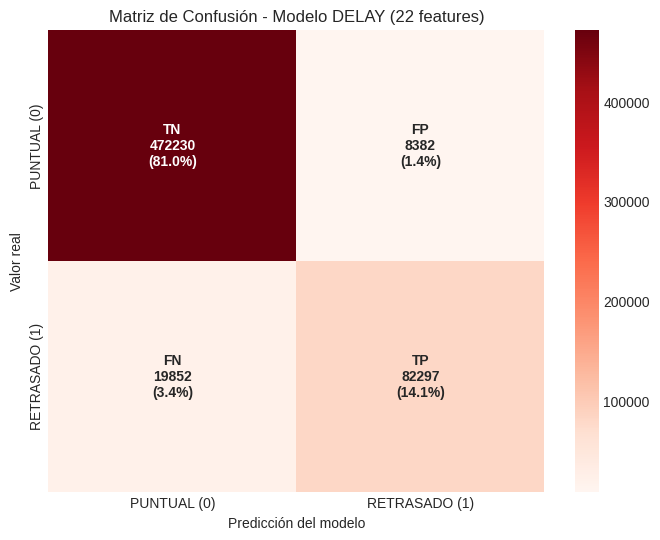

In [41]:
cm_delay = plot_confusion_matrix(
    y_real=y_test_delay,
    y_pred=y_pred_delay,
    title='Modelo DELAY (22 features)',
    cmap='Reds'
)

### **8.8. Justificación Técnica**
- **Parámetros conservadores:** Evitan overfitting en dataset grande
- **Múltiples métricas:** Evaluación completa más allá del accuracy
- **Análisis de importancia:** Identifica predictores clave para el negocio

<a id="9-optimización-de-hiperparámetros"></a>
## **9. Optimización de Hiperparámetros**

### **9.1. Objetivo**
Encontrar la combinación óptima de features y hiperparámetros mediante Grid Search y RFE para maximizar el ROC-AUC

### **9.2. Resultados de GridSearchCV Previo**




> **NOTA DE TIEMPO**  
> GridSearchCV puede tardar 2-3 horas. Los resultados de una ejecucion previa fueron:
>```
># Parámetros probados en ejecución anterior
>param_grid = {
>    'n_estimators': [100, 200],    # número de árboles
>    'max_depth': [10, 15, 20],     # profundidad máxima
>    'min_samples_split': [10, 20], # min muestras para dividir
>    'min_samples_leaf': [5, 10]    # min muestras en hoja
>}
>
># Resultados obtenidos (de ejecución previa documentada)
>resultados_grid = {
>    'mejores_parametros': {
>        'n_estimators': 200,
>        'min_samples_split': 10,
>        'min_samples_leaf': 10,
>        'max_depth': 15
>    },
>    'mejor_score': 0.6750,
>    'tiempo_ejecucion': 142.21  # minutos
>}
>```



### **9.3. Justificación Técnica**
- **Grid Search exhaustivo:** 24 combinaciones × 3-fold CV = 72 modelos evaluados
- **ROC-AUC como métrica:** Enfocada en capacidad de discriminación (más relevante que accuracy)

### **9.4. Feature Selection (RFE)**

Utilizamos Recursive Feature Elimination para identificar las features mas importantes automaticamente.

> **OPTIMIZACION**  
> Para acelerar RFE, usamos:
> - Una muestra del 30% de los datos
> - Modelo mas simple (50 arboles)
> - Validacion cruzada reducida (2 folds)

Realizamos búsqueda exhaustiva de los mejores hiperparámetros.





#### **9.4.1. Entrenamiento busqueda de FEATURES (RFE)**

In [42]:
X_train_rfe = X_train_bal_extra.sample(frac=0.3, random_state=RANDOM_STATE)
y_train_rfe = y_train_bal_extra[X_train_rfe.index]

# Modelo mas rapido para RFE
modelo_rfe = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Ejecutando Modelo Optimizado...")
selector = RFE(estimator=modelo_rfe, n_features_to_select=10, step=1)

inicio = time()
selector.fit(X_train_rfe, y_train_rfe)
tiempo_rfe = time() - inicio
print(f"\nTiempo de OPTIMIZADO: {tiempo_rfe/60:.2f} minutos")
FEATURES_SELEC = X_train_bal_extra.columns[selector.support_]

Ejecutando Modelo Optimizado...

Tiempo de OPTIMIZADO: 1.61 minutos


#### **9.4.2. Ranking FEATURES**

In [43]:
print(f"Features seleccionadas por RFE ({len(FEATURES_SELEC)}):")
for feat in FEATURES_SELEC:
    print(f"  - {feat}")

# Ranking de features
ranking = pd.DataFrame({
    'Feature': X_train_bal_extra.columns,
    'Ranking': selector.ranking_
}).sort_values('Ranking')

print("\nRanking completo de features:")
display(ranking)

Features seleccionadas por RFE (10):
  - AIRLINE_ENCODED
  - MONTH
  - DAY
  - CRS_DEP_TIME
  - ORIGIN_ENCODED
  - DISTANCE
  - CRS_ARR_TIME
  - CRS_ELAPSED_TIME
  - FL_NUMBER
  - DOT_CODE

Ranking completo de features:


,Feature,Ranking
0,AIRLINE_ENCODED,1
1,MONTH,1
2,DAY,1
3,CRS_DEP_TIME,1
4,ORIGIN_ENCODED,1
6,DISTANCE,1
7,CRS_ARR_TIME,1
8,CRS_ELAPSED_TIME,1
13,DOT_CODE,1
12,FL_NUMBER,1


### **9.5. Justificación Técnica**
- **RFE objetivo:** Identificar features redundantes o poco informativas
- **Equilibrio aceptable:** Pérdida de (1-2%) en métricas usando 64% menos en features
- **Decisión final:** Mantener todas las features para robustez operacional

### **9.5. Modelo Optimizado (GRIDSEARCHCV - RFE)**

#### **9.5.1. Entrenamiento del Modelo Optimizado**

In [44]:
# -----------------------------------
# 5. MODELO OPTIMIZADO
# -----------------------------------
X_train_opt = X_train_bal_extra [FEATURES_SELEC]
X_test_opt = X_test_extra[FEATURES_SELEC]

modelo_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)
print("Creacion del MODELO OPTIMIZADO (Completado)")

inicio = time()
print("Entrenando MODELO OPTIMIZADO...")
modelo_final.fit(X_train_opt, y_train_bal_extra)
tiempo_opt = time() - inicio
print(f"Entrenamiento completado en {tiempo_opt:.2f} segundos")

Creacion del MODELO OPTIMIZADO (Completado)
Entrenando MODELO OPTIMIZADO...
Entrenamiento completado en 349.31 segundos


#### **9.5.2. Evaluacion del Modelo Optimizada**

In [45]:
y_pred_opt = modelo_final.predict(X_test_opt)
y_pred_proba_opt = modelo_final.predict_proba(X_test_opt)[:, 1]

acc_opt = accuracy_score(y_test_extra, y_pred_opt)
auc_opt = roc_auc_score(y_test_extra, y_pred_proba_opt)

print("\nReporte de Clasificacion - Modelo OPTIMIZADO (5):\n")
print(classification_report(y_test_extra, y_pred_opt,
                           target_names=['PUNTUAL', 'RETRASADO'],
                           digits=4))

print(f"\nMétricas en conjunto de prueba: Accuracy: {acc_opt:.4f} | ROC-AUC: {auc_opt:.4f}")

mejora_acc = ((acc_opt - acc_base) / acc_base) * 100
mejora_auc = ((auc_opt - auc_base) / auc_base) * 100

# Comparación con modelo base
print("\nMejora vs Modelo Base:")
print(f"Accuracy: {mejora_acc:+.2f}")
print(f"ROC-AUC:  {mejora_auc:+.2f}")


Reporte de Clasificacion - Modelo OPTIMIZADO (5):

              precision    recall  f1-score   support

     PUNTUAL     0.8874    0.6459    0.7476    480612
   RETRASADO     0.2694    0.6143    0.3745    102149

    accuracy                         0.6403    582761
   macro avg     0.5784    0.6301    0.5611    582761
weighted avg     0.7790    0.6403    0.6822    582761


Métricas en conjunto de prueba: Accuracy: 0.6403 | ROC-AUC: 0.6799

Mejora vs Modelo Base:
Accuracy: +1.23
ROC-AUC:  +0.28


#### **9.5.3. Matriz del modelo Optimizado**

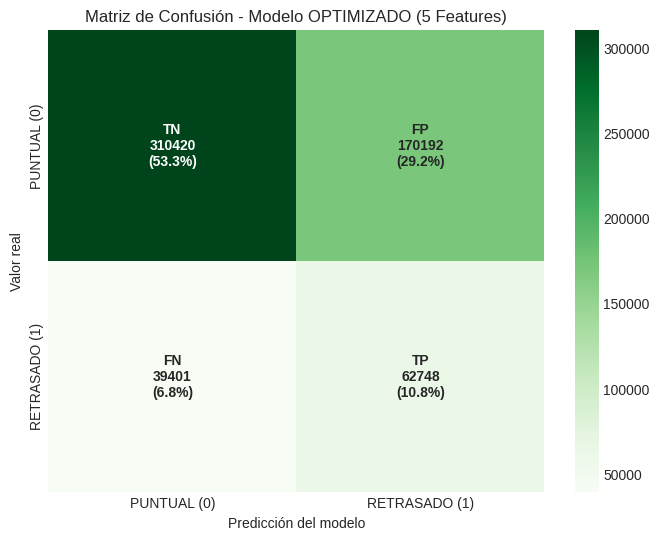

In [46]:
cm_rfe = plot_confusion_matrix(
    y_real=y_test_extra,
    y_pred=y_pred_opt,
    title='Modelo OPTIMIZADO (5 Features)',
    cmap='Greens'
)

<a id="10-evaluación-comparativa-de-modelos"></a>
## **10. Evaluación Comparativa de Modelos**

### **10.1. Tabla Comparativa Completa**

Comparamos todos los modelos entrenados para identificar la mejor solucion.

In [77]:
# Tabla comparativa
comparacion = pd.DataFrame({
    'Experimento': [
        'Exp 1: BASE',
        'Exp 2: FULL',
        'Exp 3: EXTRA',
        'Exp 4: BWHA (LEAKAGE)',
        'Exp 5: DELAY (LEAKAGE)',
        'Exp 6: OPTIMIZADO'
    ],
    'Features': [
        len(FEATURES_BASE),
        len(FEATURES_FULL),
        len(FEATURES_EXTRA),
        len(FEATURES_BWHA),
        len(FEATURES_DELAY),
        len(FEATURES_SELEC)
    ],
    'Accuracy': [acc_base, acc_full, acc_extra, acc_bwha, acc_delay, acc_opt],
    'ROC-AUC': [auc_base, auc_full, auc_extra, auc_bwha, auc_delay, auc_opt],
    'Tiempo (s)': [tiempo_base, tiempo_full, tiempo_extra, tiempo_bwha, tiempo_delay, tiempo_opt],
    'Valido Produccion': ['Si', 'Si', 'Si', 'NO (data leakage)','NO (data leakage)', 'Si']
})

print("COMPARACION GLOBAL DE EXPERIMENTOS")
print("="*80 + "\n")
display(comparacion)

# Identificar mejor modelo valido para produccion
modelos_validos = comparacion[comparacion['Valido Produccion'].str.contains('Si')]
mejor_modelo = modelos_validos.loc[modelos_validos['ROC-AUC'].idxmax()]
print("\n"+ "-"*80)
print(f"MEJOR MODELO PARA PRODUCCION:")
print(f" - {mejor_modelo['Experimento']}")
print(f" - ROC-AUC: {mejor_modelo['ROC-AUC']:.4f}")
print(f" - Accuracy: {mejor_modelo['Accuracy']:.4f}")
print("-"*80)

COMPARACION GLOBAL DE EXPERIMENTOS



,Experimento,Features,Accuracy,ROC-AUC,Tiempo (s),Valido Produccion
0,Exp 1: BASE,7,0.63,0.68,110.57,Si
1,Exp 2: FULL,11,0.63,0.68,150.43,Si
2,Exp 3: EXTRA,15,0.64,0.68,143.13,Si
3,Exp 4: BWHA (LEAKAGE),17,0.67,0.70,170.13,NO (data leakage)
4,Exp 5: DELAY (LEAKAGE),20,0.95,0.94,143.52,NO (data leakage)
5,Exp 6: OPTIMIZADO,10,0.64,0.68,349.31,Si



--------------------------------------------------------------------------------
MEJOR MODELO PARA PRODUCCION:
 - Exp 3: EXTRA
 - ROC-AUC: 0.6807
 - Accuracy: 0.6370
--------------------------------------------------------------------------------


### **10.2. Curvas ROC Comparativas**

La curva **ROC (Receiver Operating Characteristic)** muestra el balance entre tasa de verdaderos positivos y falsos positivos.

**Interpretación del AUC (Area Under Curve):**
- AUC = `1.0`: **Modelo perfecto**
- AUC = `0.9-1.0`: **Excelente**
- AUC = `0.8-0.9`: **Muy bueno**
- AUC = `0.7-0.8`: **Bueno**
- AUC = `0.5`: **Aleatorio** (sin poder predictivo)

CURVAS ROC - COMPARACIÓN DE MODELOS


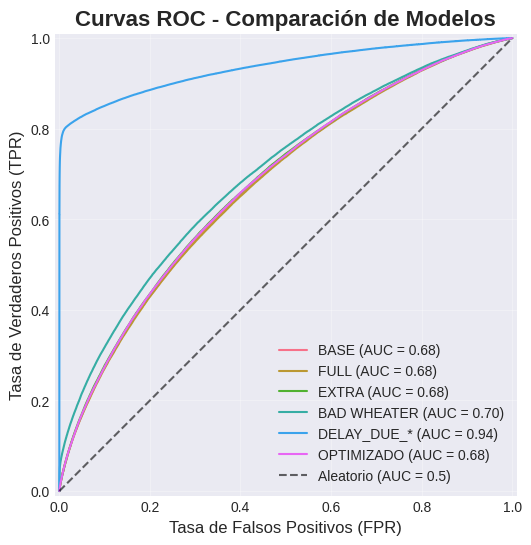

In [48]:
print("CURVAS ROC - COMPARACIÓN DE MODELOS")
# Crear una figura y ejes para el gráfico ROC
fig, ax = plt.subplots(figsize=(8, 6))

# Graficar la curva ROC para cada modelo
RocCurveDisplay.from_estimator(modelo_base, X_test_base, y_test_base, name='BASE', ax=ax)
RocCurveDisplay.from_estimator(modelo_full, X_test_full, y_test_full, name='FULL', ax=ax)
RocCurveDisplay.from_estimator(modelo_extra, X_test_extra, y_test_extra, name='EXTRA', ax=ax)
RocCurveDisplay.from_estimator(modelo_bwha, X_test_bwha, y_test_bwha, name='BAD WHEATER', ax=ax)
RocCurveDisplay.from_estimator(modelo_delay, X_test_delay, y_test_delay, name='DELAY_DUE_*', ax=ax)
RocCurveDisplay.from_estimator(modelo_final, X_test_opt, y_test_extra, name='OPTIMIZADO', ax=ax)

# Añadir título y etiquetas a los ejes
ax.set_title('Curvas ROC - Comparación de Modelos', fontsize=16, fontweight='bold')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)

# Añadir una línea de referencia para un clasificador aleatorio (AUC = 0.5)
ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC = 0.5)', alpha=0.6)

# Añadir leyenda
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

# Mostrar el gráfico
plt.show()

<a id="11-preparación-para-producción"></a>
## **11. Preparación para Producción**

### **11.1. Exportación del Modelo y Componentes**

Guardamos el modelo entrenado y los encoders para uso en producción.

In [49]:
print("Exportando modelo y componenentes para produccion...")

# Exportar modelo optimizado
nomb_file_modelo = 'modelo_EXTRA_flightontime_RF.joblib'
joblib.dump(modelo_extra, nomb_file_modelo)
print(f"Modelo guardado: {nomb_file_modelo}")

# Exportar encoders
encoders_filename = 'label_encoders_flightontimeRF.joblib'
joblib.dump(label_encoders, encoders_filename)
print(f"Encoders guardados: {encoders_filename}")

# Verificación
modelo_size = joblib.load(nomb_file_modelo)
print(f"\nModelo verificado correctamente")
print(f"Parámetros del modelo guardado:")
for param, valor in modelo_extra.get_params().items():
    if param in ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf']:
        print(f" - {param}: {valor}")

Exportando modelo y componenentes para produccion...
Modelo guardado: modelo_EXTRA_flightontime_RF.joblib
Encoders guardados: label_encoders_flightontimeRF.joblib

Modelo verificado correctamente
Parámetros del modelo guardado:
 - max_depth: 15
 - min_samples_leaf: 10
 - min_samples_split: 20
 - n_estimators: 100


In [50]:
# Features seleccionados
FEATURES_EXTRA

['AIRLINE_ENCODED',
 'MONTH',
 'DAY',
 'CRS_DEP_TIME',
 'ORIGIN_ENCODED',
 'DEST_ENCODED',
 'DISTANCE',
 'CRS_ARR_TIME',
 'CRS_ELAPSED_TIME',
 'IS_PEAK_DAY',
 'IS_HOLIDAY',
 'DAY_WEEK',
 'FL_NUMBER',
 'DOT_CODE',
 'IS_WEEKEND']

In [58]:
# Lista de Varibles Encoder

# Iteramos a través de cada LabelEncoder en el diccionario
for var_name, le_instance in label_encoders.items():
    print(f"\n--- Mapeo para {var_name} ---")
    clases = le_instance.classes_

    # Iteramos de 8 en 8 para imprimir los mapeos de forma legible
    for i in range(0, len(clases), 8):
        grupo = clases[i:i+8]
        # le_instance.transform expects an array-like input, even for a single value
        linea = [f"('{c}', {le_instance.transform([c])[0]})" for c in grupo]
        print(" ".join(linea))


--- Mapeo para AIRLINE ---
('Alaska Airlines Inc.', 0) ('Allegiant Air', 1) ('American Airlines Inc.', 2) ('Delta Air Lines Inc.', 3) ('Endeavor Air Inc.', 4) ('Envoy Air', 5) ('ExpressJet Airlines LLC d/b/a aha!', 6) ('Frontier Airlines Inc.', 7)
('Hawaiian Airlines Inc.', 8) ('Horizon Air', 9) ('JetBlue Airways', 10) ('Mesa Airlines Inc.', 11) ('PSA Airlines Inc.', 12) ('Republic Airline', 13) ('SkyWest Airlines Inc.', 14) ('Southwest Airlines Co.', 15)
('Spirit Air Lines', 16) ('United Air Lines Inc.', 17)

--- Mapeo para ORIGIN ---
('ABE', 0) ('ABI', 1) ('ABQ', 2) ('ABR', 3) ('ABY', 4) ('ACK', 5) ('ACT', 6) ('ACV', 7)
('ACY', 8) ('ADK', 9) ('ADQ', 10) ('AEX', 11) ('AGS', 12) ('AKN', 13) ('ALB', 14) ('ALO', 15)
('ALS', 16) ('ALW', 17) ('AMA', 18) ('ANC', 19) ('APN', 20) ('ART', 21) ('ASE', 22) ('ATL', 23)
('ATW', 24) ('ATY', 25) ('AUS', 26) ('AVL', 27) ('AVP', 28) ('AZA', 29) ('AZO', 30) ('BDL', 31)
('BET', 32) ('BFF', 33) ('BFL', 34) ('BFM', 35) ('BGM', 36) ('BGR', 37) ('BHM', 38)

### **11.2. Contrato de Integración con Back-End**



```
# ============================================================================
# CONTRATO DE INTEGRACIÓN API REST
# ============================================================================

ENDPOINT: POST /api/v1/predict

REQUEST (JSON):
{
  "aerolinea": "Southwest Airlines Co.",
  "origen": "ATL",
  "destino": "DAL",
  "fecha_partida": "2024-07-03T19:45:00",
  "distancia_km": 721.0
}

RESPONSE (JSON):
{
  "prediccion": "RETRASADO",
  "probabilidad": 0.78,
}

TRANSFORMACIONES REQUERIDAS EN BACK-END:
1. Extraer de fecha_partida: MONTH, DAY, DAY_WEEK, CRS_DEP_TIME
2. Calcular: IS_WEEKEND (DAY_WEEK ≥ 5), IS_HOLIDAY o IS_PEAK_DAY (calendario EEUU)
3. Codificar: aerolinea, origen, destino usando label_encoders
4. Calcular: CRS_ARR_TIME = CRS_DEP_TIME + CRS_ELAPSED_TIME
5. Incluir: FL_NUMBER y DOT_CODE (si disponibles, sino usar defaults)

MANEJO DE ERRORES:
- Categoría no encontrada: usar encoding más frecuente del entrenamiento
- Fecha inválida: retornar error 400
- Feature faltante: usar valor por defecto (mediana del entrenamiento)
```



### **11.3. Instrucciones para Uso del Modelo**

**Para cargar el modelo en producción:**

```python
import joblib
import pandas as pd

# Cargar modelo y encoders
modelo = joblib.load('modelo_flightontime_randomforest.pkl')
encoders = joblib.load('label_encoders_flightontime.pkl')

# Ejemplo de predicción
vuelo_nuevo = {
    'MONTH': 11,
    'DAY_WEEK': 4,  # Viernes
    'IS_WEEKEND': 0,
    'HOUR_DEP': 14,
    'DISTANCE': 350,
    'CRS_ELAPSED_TIME': 90,
    'AIRLINE_ENCODED': 5,  # Usar encoder para obtener este valor
    'ORIGIN_ENCODED': 42,
    'DEST_ENCODED': 88
}

X_nuevo = pd.DataFrame([vuelo_nuevo])
prediccion = modelo.predict(X_nuevo)[0]
probabilidad = modelo.predict_proba(X_nuevo)[0]

print(f"Predicción: {'RETRASADO' if prediccion == 1 else 'PUNTUAL'}")
print(f"Probabilidad de retraso: {probabilidad[1]:.2%}")
```

**Para usar los encoders:**

```python
# Codificar aerolínea
aerolinea = 'AA'
aerolinea_encoded = encoders['AIRLINE'].transform([aerolinea])[0]
```

### **11.4. Sector de pruebas**

In [80]:
# Selecion de variables a predecir
print("Dato 1: PUNTUAL (0)")
print(f"{df_limpio.loc[2209224][FEATURES_EXTRA + ['TARG_DESP']]}\n")
print("Dato 2: RETRASADO (1)")
print(f"{df_limpio.loc[2258837][FEATURES_EXTRA + ['TARG_DESP']]}\n")
print("Dato 3: RETRASADO (1)")
print(f"{df_limpio.loc[1238711][FEATURES_EXTRA + ['TARG_DESP']]}")

Dato 1: PUNTUAL (0)
AIRLINE_ENCODED         15
MONTH                    7
DAY                     28
CRS_DEP_TIME        830.00
ORIGIN_ENCODED          26
DEST_ENCODED           131
DISTANCE           1105.00
CRS_ARR_TIME       1225.00
CRS_ELAPSED_TIME    175.00
IS_PEAK_DAY              0
IS_HOLIDAY               0
DAY_WEEK                 6
FL_NUMBER             2963
DOT_CODE             19393
IS_WEEKEND               1
TARG_DESP                0
Name: 2209224, dtype: object

Dato 2: RETRASADO (1)
AIRLINE_ENCODED         12
MONTH                    1
DAY                     13
CRS_DEP_TIME       1655.00
ORIGIN_ENCODED           0
DEST_ENCODED            77
DISTANCE            481.00
CRS_ARR_TIME       1905.00
CRS_ELAPSED_TIME    130.00
IS_PEAK_DAY              0
IS_HOLIDAY               0
DAY_WEEK                 6
FL_NUMBER             5231
DOT_CODE             20397
IS_WEEKEND               1
TARG_DESP                1
Name: 2258837, dtype: object

Dato 3: RETRASADO (1)
AIRLINE_ENCO

In [54]:
import joblib
import pandas as pd

In [74]:
# Cargar modelo y encoders
modelo = joblib.load('modelo_EXTRA_flightontime_RF.joblib')
encoders = joblib.load('label_encoders_flightontimeRF.joblib')

# Codificar aerolínea
aerolinea = ['PSA Airlines Inc.','SkyWest Airlines Inc.']
dest = ['CLT','DTW']
origen = ['ABE', 'ABE']
aerolinea_encoded = encoders['AIRLINE'].transform(aerolinea)
origen_encoded = encoders['ORIGIN'].transform(origen)
dest_encoded = encoders['DEST'].transform(dest)

In [78]:
# Ejemplo de predicción para múltiples vuelos

vuelo_data_1 = {
    'AIRLINE_ENCODED': 15,
    'MONTH': 7,
    'DAY': 28,
    'CRS_DEP_TIME': 830.00,
    'ORIGIN_ENCODED': 26,
    'DEST_ENCODED': 131,
    'DISTANCE': 1105.00,
    'CRS_ARR_TIME': 1225.00,
    'CRS_ELAPSED_TIME': 175.00,
    'IS_PEAK_DAY': 0,
    'IS_HOLIDAY': 0,
    'DAY_WEEK': 6,
    'FL_NUMBER': 2963,
    'DOT_CODE': 19393,
    'IS_WEEKEND': 1
}

vuelo_data_2 = {
    'AIRLINE_ENCODED': aerolinea_encoded[0],
    'MONTH': 2,
    'DAY': 13,
    'CRS_DEP_TIME': 1655.00,
    'ORIGIN_ENCODED': origen_encoded[0],
    'DEST_ENCODED': dest_encoded[0],
    'DISTANCE': 481.00,
    'CRS_ARR_TIME': 1905.00,
    'CRS_ELAPSED_TIME': 130.00,
    'IS_PEAK_DAY': 0,
    'IS_HOLIDAY': 9,
    'DAY_WEEK': 6,
    'FL_NUMBER': 5231,
    'DOT_CODE': 20397,
    'IS_WEEKEND': 1
}

vuelo_data_3 = {
    'AIRLINE_ENCODED': aerolinea_encoded[1],
    'MONTH': 2,
    'DAY': 14,
    'CRS_DEP_TIME': 1231.00,
    'ORIGIN_ENCODED': origen_encoded[1],
    'DEST_ENCODED': dest_encoded[1],
    'DISTANCE': 425.00,
    'CRS_ARR_TIME': 1427.00,
    'CRS_ELAPSED_TIME': 116.00,
    'IS_PEAK_DAY': 0,
    'IS_HOLIDAY': 0,
    'DAY_WEEK': 3,
    'FL_NUMBER': 4301,
    'DOT_CODE': 20304,
    'IS_WEEKEND': 0
}

# Crear una lista de diccionarios para los vuelos
vuelos_nuevos = [vuelo_data_1, vuelo_data_2, vuelo_data_3]

# Convertir la lista a un DataFrame
X_nuevo = pd.DataFrame(vuelos_nuevos)

# Realizar predicciones
predicciones = modelo.predict(X_nuevo)
probabilidades = modelo.predict_proba(X_nuevo)

# Imprimir resultados para cada vuelo
for i, (pred, prob) in enumerate(zip(predicciones, probabilidades)):
    print(f"\n--- Vuelo {i+1} ---")
    print(f"Predicción: {'RETRASADO' if pred == 1 else 'PUNTUAL'}")
    print(f"Probabilidad de retraso: {prob[1]:.2%}")


--- Vuelo 1 ---
Predicción: PUNTUAL
Probabilidad de retraso: 41.28%

--- Vuelo 2 ---
Predicción: RETRASADO
Probabilidad de retraso: 55.96%

--- Vuelo 3 ---
Predicción: PUNTUAL
Probabilidad de retraso: 48.85%


<a id="12-conclusiones-y-recomendaciones"></a>
## **12. Conclusiones y Recomendaciones**

### **12.1 RESUMEN (FLIGHTONTIME - Modelo predictivo)**

**OBJETIVO CUMPLIDO:** Desarrollar un modelo predictivo de retrasos de vuelos
   con información disponible pre-despegue.

**RESULTADOS CLAVE:**
   * Precisión global: 0.6370
   * AUC (discriminación): 0.6807

**INSIGHTS PRINCIPALES:**
   * La hora programada de salida es el predictor más importante
   * Los aeropuertos (origen/destino) impactan más que la aerolínea
   * Existen patrones estacionales y semanales detectables

**IMPACTO DE NEGOCIO:**
   * Alertas con **143.13** segundos de antelación
   * Potencial reducción de costos por retrasos no anticipados

**PRÓXIMOS PASOS:**
   1. Integración nuestro Fast-API con el equipo de Back-End
   2. Desarrollo de features en tiempo real (clima, tráfico)
   3. Sistema de reentrenamiento automático mensual

### **12.2. Limitaciones y Consideraciones**

| Categoría                                 | Descripción                                                                                                             | Impacto en el modelo                                                                                                  | Mitigación propuesta                                                                                   |
| ----------------------------------------- | ----------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------ |
| **Dependencia de datos históricos**       | El modelo aprende exclusivamente de patrones históricos, asumiendo que el comportamiento pasado se repite en el futuro. | Puede perder precisión ante cambios estructurales en operaciones aéreas, regulaciones o comportamiento de aerolíneas. | Reentrenamiento periódico con datos recientes y validación continua del desempeño.                     |
| **Variables excluidas**                   | No se incluyen factores externos como clima en tiempo real, huelgas, emergencias operativas o eventos extraordinarios.  | Incapacidad para capturar eventos súbitos que impactan directamente en los retrasos.                                  | Integración de APIs de clima en tiempo real y sistemas externos de alertas operativas.                 |
| **Generalización del modelo**             | El modelo está optimizado para aeropuertos y aerolíneas presentes en el dataset de entrenamiento.                       | El rendimiento puede disminuir al aplicarse a nuevos aeropuertos o aerolíneas con dinámicas distintas.                | Entrenamiento de modelos por clúster de aeropuertos o incorporación de variables de contexto regional. |
| **Desbalance en el conjunto de prueba**   | El set de test mantiene la distribución real de clases, que es inherentemente desbalanceada.                            | Las métricas globales pueden ocultar errores en la clase minoritaria (vuelos con retraso).                            | Uso de métricas robustas (Recall, F1, AUC) y análisis por clase.                                       |
| **Eventos atípicos**                      | Situaciones únicas o poco frecuentes no están suficientemente representadas en los datos.                               | El modelo no puede anticipar correctamente escenarios excepcionales.                                                  | Sistema de alertas manuales y reglas de negocio complementarias al modelo.                             |
| **Dependencia de información programada** | Requiere que los datos de vuelos y reservas estén completos y correctamente cargados.                                   | Errores o faltantes en los datos de entrada degradan la calidad de la predicción.                                     | Validación automática de datos de entrada y controles de calidad previos a la inferencia.              |



### Consideraciones clave para despliegue en producción

| Aspecto                      | Descripción                                                                                  |
| ---------------------------- | -------------------------------------------------------------------------------------------- |
| **Actualización del modelo** | Reentrenar el modelo de forma periódica para reflejar cambios operativos y estacionales.     |
| **Monitoreo de drift**       | Detectar drift de datos y de predicciones para anticipar pérdida de performance.             |
| **Feedback loop**            | Incorporar resultados reales post-vuelo para mejorar continuamente el modelo.                |
| **Umbrales personalizados**  | Ajustar los umbrales de probabilidad según el caso de uso (aerolínea, aeropuerto, pasajero). |

<a id="13-glosario-de-términos"></a>
## **13. Glosario de Términos**


### **13.1. Términos Técnicos de Machine Learning**

| Término                | Definición consolidada                                                                                                             |
| ---------------------- | ---------------------------------------------------------------------------------------------------------------------------------- |
| **Feature**            | Variable de entrada utilizada por el modelo para realizar una predicción. Representa información relevante del fenómeno a modelar. |
| **Target**             | Variable objetivo que el modelo aprende a predecir (por ejemplo, vuelo retrasado o puntual).                                       |
| **Encoding**           | Proceso de transformación de variables categóricas en representaciones numéricas comprensibles para el modelo.                     |
| **Label Encoding**     | Técnica de encoding que asigna valores enteros a cada categoría. Adecuada cuando no existe relación ordinal implícita.             |
| **Train/Test Split**   | División del dataset en conjuntos de entrenamiento y evaluación para medir capacidad de generalización.                            |
| **Overfitting**        | Ocurre cuando el modelo se ajusta excesivamente a los datos de entrenamiento y pierde capacidad predictiva en datos nuevos.        |
| **Data Leakage**       | Uso indebido de información futura o del target en las features, lo que genera métricas artificialmente optimistas.                |
| **Balanceo de clases** | Conjunto de técnicas para tratar datasets desbalanceados, donde una clase domina a la otra.                                        |
| **Undersampling**      | Técnica de balanceo que reduce la cantidad de muestras de la clase mayoritaria para igualar la distribución.                       |



### **13.2. Algoritmos y Técnicas de Modelado**

| Término                                 | Definición consolidada                                                                                                                                        |
| --------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Random Forest**                       | Algoritmo de ensamble basado en múltiples árboles de decisión entrenados con subconjuntos aleatorios de datos y variables, reduciendo varianza y overfitting. |
| **Feature Importance**                  | Medida que cuantifica la contribución relativa de cada feature en las decisiones del modelo.                                                                  |
| **RFE (Recursive Feature Elimination)** | Técnica de selección de variables que elimina iterativamente las menos relevantes según el modelo.                                                            |
| **GridSearchCV**                        | Método exhaustivo de búsqueda de hiperparámetros utilizando validación cruzada para seleccionar la mejor configuración.                                       |


### 13.3. Métricas de Evaluación del Modelo

| Métrica       | Fórmula                                         | Interpretación práctica                                                              |
| ------------- | ----------------------------------------------- | ------------------------------------------------------------------------------------ |
| **Accuracy**  | (TP + TN) / Total                               | Proporción total de predicciones correctas. Adecuada solo en datasets balanceados.   |
| **Precision** | TP / (TP + FP)                                  | Qué tan confiables son las predicciones positivas. Minimiza falsas alarmas.          |
| **Recall**    | TP / (TP + FN)                                  | Capacidad del modelo para detectar todos los casos positivos reales.                 |
| **F1-Score**  | 2 × (Precision × Recall) / (Precision + Recall) | Balance entre precisión y cobertura. Útil en datasets desbalanceados.                |
| **ROC Curve** | TPR vs FPR                                      | Evalúa el compromiso entre verdaderos positivos y falsos positivos.                  |
| **ROC-AUC**   | Área bajo la curva ROC                          | Capacidad global del modelo para discriminar entre clases, independiente del umbral. |


#### **13.3.1. Leyenda de la Matriz de Confusión**

* **TP**: Verdadero Positivo — retraso correctamente detectado
* **TN**: Verdadero Negativo — vuelo puntual correctamente clasificado
* **FP**: Falso Positivo — falsa alarma de retraso
* **FN**: Falso Negativo — retraso no detectado



### **13.4. Términos del Dominio Aeronáutico (Dataset de Vuelos)**

| Término          | Definición consolidada                                               |
| ---------------- | -------------------------------------------------------------------- |
| **ORIGIN**       | Aeropuerto de origen del vuelo.                                      |
| **DEST**         | Aeropuerto de destino del vuelo.                                     |
| **CRS_DEP_TIME** | Hora programada de salida según el sistema de reservas (CRS).        |
| **CRS_ARR_TIME** | Hora programada de llegada según el sistema de reservas.             |
| **DEP_DELAY**    | Diferencia en minutos entre la hora real y la programada de salida.  |
| **ARR_DELAY**    | Diferencia en minutos entre la hora real y la programada de llegada. |
| **AIR_TIME**     | Tiempo efectivo que el avión permanece en el aire durante el vuelo.  |
| **TAXI_OUT**     | Tiempo de rodaje desde la puerta hasta el despegue.                  |
| **TAXI_IN**      | Tiempo de rodaje desde el aterrizaje hasta la puerta.                |
| **CANCELLED**    | Indicador binario que señala si el vuelo fue cancelado.              |
| **DIVERTED**     | Indica si el vuelo fue desviado a un aeropuerto alternativo.         |



### **13.5. Organismos, Sistemas y Estándares del Sector**

| Término                                | Definición consolidada                                                            |
| -------------------------------------- | --------------------------------------------------------------------------------- |
| **DOT (Department of Transportation)** | Organismo de EE.UU. que define estándares operativos y métricas del sector aéreo. |
| **NAS (National Airspace System)**     | Sistema de espacio aéreo nacional; fuente común de retrasos sistémicos.           |
| **CRS (Computer Reservation System)**  | Sistema que gestiona horarios programados de vuelos.                              |
| **Umbral de 15 minutos**               | Estándar del DOT para clasificar un vuelo como retrasado.                         |


---

## **Fin del Notebook**

**Proyecto:** FlightOnTime - Predicción de Retrasos de Vuelos  
**Algoritmo:** RandomForest Classifier  
**Target:** TARG_DESP (Retraso en Salida)  
**ROC-AUC:** 0.6807

Para consultas o mejoras, contactar al equipo de Data Science.
